In [1]:
import torch as t
import numpy as np 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F 
import torch.distributions as dist
import matplotlib.pyplot as plt 
import random
from scipy.integrate import solve_ivp
from Functions import *

j = complex(0, 1)

0.39038390383903837 1.6403766342415644


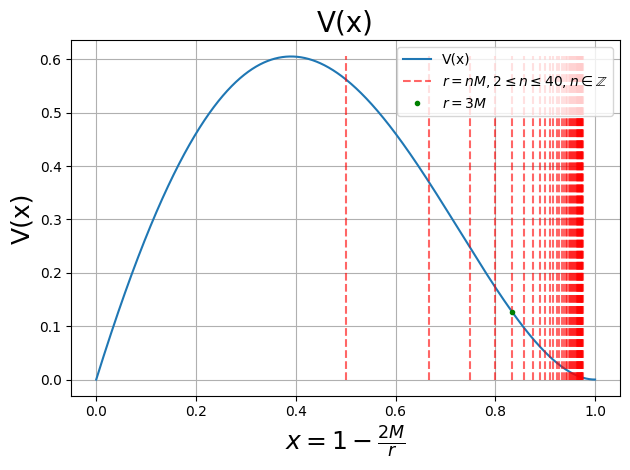

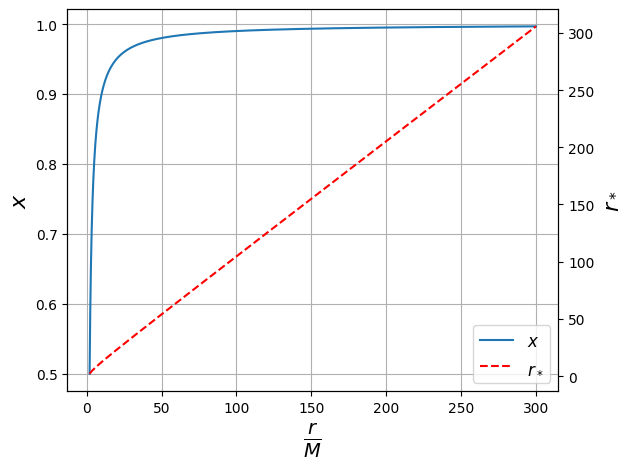

In [2]:
M = 1.0/2
l = 2#
eps = 1e-15
x = np.linspace(0, 1, 100000)
r = np.linspace(2 + eps, 300, 100000)
x_coord = r_to_x(r, M)
rstar_coord = r_to_rstar(r, M)

def Vx(x, M, l):
    return x*(1-x)**2/(4*M**2)*(l*(l+1) - 3*(1-x))

V_PINN = Vx(x, M, l)

peak_idx = np.argmax(V_PINN)
print(x[peak_idx], x_to_r(x[peak_idx], M))

light_ring = 1-2*M/3*M

radii = np.array(range(39)) + 2

# xs = []
# for r in radii:
#     xs.append(r_to_x(r, M))

plt.figure()
plt.plot(x, V_PINN, label = r'V(x)')
plt.vlines(1 - 2*M/radii, [0]*len(radii), [np.max(V_PINN)]*len(radii), 'r', 'dashed', alpha = 0.6, label = r'$ r = nM, 2 \leq n \leq 40, n \in \mathbb{Z}$')
plt.plot(light_ring, Vx(light_ring, M, l), '.', color = 'green', label = r'$r = 3M$')
plt.xlabel(r'$x = 1 - \frac{2M}{r}$', fontsize = 18)
plt.ylabel('V(x)', fontsize = 18)
plt.title('V(x)', fontsize = 20)
plt.tight_layout()
plt.grid()
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
line1 = ax1.plot(r, x_coord, label=r'$x$')
ax1.set_xlabel(r'$\frac{r}{M}$', fontsize=20)
ax1.set_ylabel(r'$x$', fontsize=16)
ax1.tick_params(axis = 'y')
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(r, rstar_coord, color = 'red', linestyle='--', label=r'$r_*$')
ax2.set_ylabel(r'$r_*$', fontsize=16)
ax2.tick_params(axis='y')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize = 'large', loc='lower right')
fig.tight_layout()  
plt.show()


c:\Users\danie\Documents\MSci-Project\MSci-Project\Functions.py:21: RuntimeWarning: divide by zero encountered in divide
  return 2*M/(1-x)


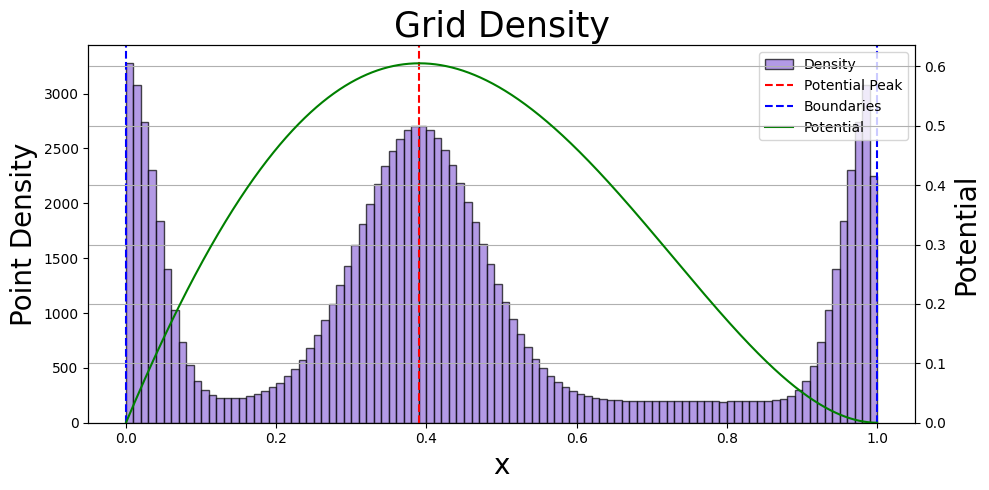

In [3]:
x_test = np.linspace(0, 1, 1000)

def dense_grid(n_points, x_peak, peak_width, peak_intensity, bound_width, bound_intensity):

    ref_x = np.linspace(0, 1, 25000)
    weights = 1.0 + peak_intensity*np.exp(-(ref_x - x_peak)**2/(2*peak_width**2)) 
    weights += bound_intensity*np.exp(-(ref_x - 1)**2/(2*bound_width**2)) 
    weights += bound_intensity*np.exp(-(ref_x - 0)**2/(2*bound_width**2)) 
    
    cdf = np.cumsum(weights)
    cdf /= cdf[-1] 

    uniform_steps = np.linspace(0.0 + 1e-8, 1 - 1e-2, n_points)
    clustered_x = np.interp(uniform_steps, cdf, ref_x)
    clustered_x[0] = 0
    clustered_x[-1] = 1
    
    return clustered_x

M = 1.0/2
l = 2
x_peak = Vpm_peak(M = 1/2, l = 2, parity = "axial", coord = 'x')

N = 100000

x_grid = dense_grid(N, x_peak, peak_intensity = 13, peak_width = 0.08, 
                    bound_intensity = 16, bound_width = 0.04)
V_PINN = Vpm(x_to_r(x_grid, M), M, l, "axial")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.hist(x_grid, bins=100, color = 'mediumpurple', alpha = 0.7, edgecolor='black', label = 'Density')
ax1.set_xlabel("x", fontsize = 20)
ax1.set_ylabel("Point Density", fontsize = 20)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(x_grid, V_PINN, color='green', label='Potential')
ax2.set_ylabel("Potential", fontsize = 20)
ax2.tick_params(axis='y')

ax1.axvline(x_peak, color='red', linestyle='--', label='Potential Peak')
ax1.axvline(0, color='blue', linestyle='--', label='Boundaries')
ax1.axvline(1, color='blue', linestyle='--')

ax1.set_ylim(bottom = 0)
ax2.set_ylim(bottom = 0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Grid Density", fontsize = 25)
plt.tight_layout()
plt.grid()
plt.show()

x_grid = np.where(x_grid == 0, 1e-6, x_grid)
x_grid = np.where(x_grid == 1, 1 - 1e-4, x_grid)


# plt.figure()
# plt.scatter(x_test, transformed_x)
# plt.plot(x_test, np.ones_like(x_test), '.', label = 'Regular')
# plt.plot(transformed_x, np.zeros_like(x_test), '.', label = 'Transformed')
# plt.vlines(0.39, 0, 1, label = 'x = x_peak')
# plt.tight_layout()
# plt.legend()
# plt.show()

In [4]:
#RK4 solver 
def RK4_vector(derivative, IC, x_final, n, args = ()):
    x = np.linspace(IC[0], x_final, n)
    dx = x[1] - x[0]

    Y = np.zeros((n, len(IC) - 1), dtype = complex)
    Y[0] = IC[1:]

    for i in range(n - 1):
        xi = x[i]
        Yi = Y[i]

        k1 = dx*derivative(xi, Yi, *args)
        k2 = dx*derivative(xi + dx/2, Yi + k1/2, *args)
        k3 = dx*derivative(xi + dx/2, Yi + k2/2, *args)
        k4 = dx*derivative(xi + dx, Yi + k3, *args)

        Y[i + 1] = Yi + (k1 + 2*k2 + 2*k3 + k4)/6
    return x, Y

def A_full(x):
    return x*(x - 1)**2

def B_full(x, rho):
    return (3 + 4*rho)*x**2 - 4*(1 + 2*rho)*x + 2*rho + 1

def C_full(x, rho, l):
    return -(l*(l + 1) + 3*(x - 1) - 4*rho*(x - 2*rho + rho*x - 1))

def system_RK4(x, Y, rho, M, l):
    w, dw = Y

    A = x*(x - 1)**2
    B = (3 + 4*rho)*x**2 - 4*(1 + 2*rho)*x + 2*rho + 1
    C = -(l*(l + 1) + 3*(x - 1) - 4*rho*(x - 2*rho + rho*x - 1))

    d2w = -(B*dw + C*w)/A
    return np.array([dw, d2w], dtype = complex)

def system_Radau(x, Y, rho, M, l):
    w_re, w_im, dw_re, dw_im = Y

    w = w_re + 1j*w_im
    dw = dw_re + 1j*dw_im

    A = x*(x - 1)**2
    B = (3 + 4*rho)*x**2 - 4*(1 + 2*rho)*x + 2*rho + 1
    C = -(l*(l + 1) + 3*(x - 1) - 4*rho*(x - 2*rho + rho*x - 1))

    if np.abs(A) < 1e-15:
        return np.array([0.0, 0.0, 0.0, 0.0])

    d2w = -(B*dw + C*w)/A
    return [dw.real, dw.imag, d2w.real, d2w.imag]

def robin_BC_h(w0, rho, l):
    C0 = C_full(0.0, rho, l)
    B0 = B_full(0.0, rho)

    dw0 = -C0*w0/B0
    return w0, dw0

M = 0.5
l = 2
rho = -1j*complex(0.74734, -0.177921)
eps = 1e-7
w0 = complex(1, 0)
BC = robin_BC_h(w0, rho, l)
initial_state_RK4 = np.array([0.0 + eps, BC[0], BC[1]], dtype = complex)

x_vals_RK4, Y_vals = RK4_vector(system_RK4, initial_state_RK4, 
                            x_final = 1.0 - 1e-2, n = 100000, args = (rho, M, l))
w_RK4 = np.array(Y_vals[:, 0])
dw_RK4 = np.array(Y_vals[:, 1])

initial_state_Radau = [BC[0].real, BC[0].imag, BC[1].real, BC[1].imag]
sol = solve_ivp(system_Radau, 
                t_span = (eps, 1.0 - 1e-4), 
                y0 = initial_state_Radau, 
                method = 'Radau',
                args = (rho, M, l),
                rtol = 1e-10,
                atol = 1e-12)

x_vals_Radau = sol.t
w_Radau = sol.y[0] + 1j*sol.y[1]
dw_Radau = sol.y[2] + 1j*sol.y[3]

1e-07


C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


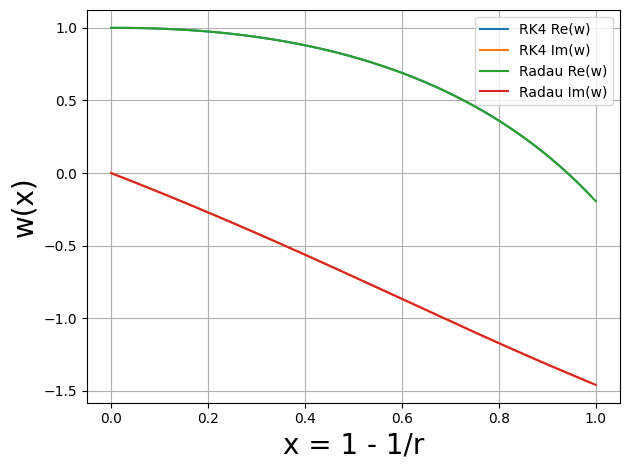

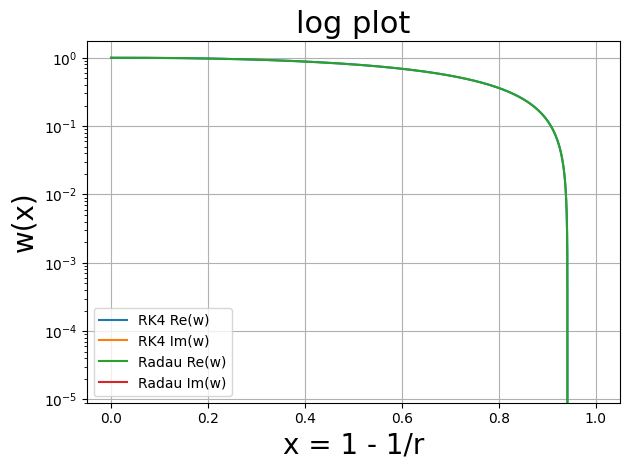

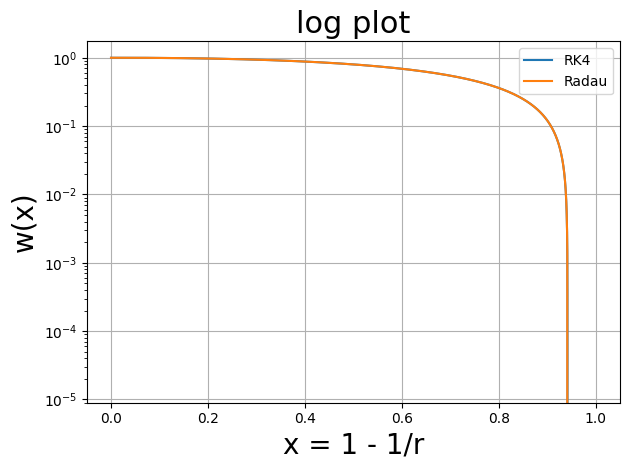

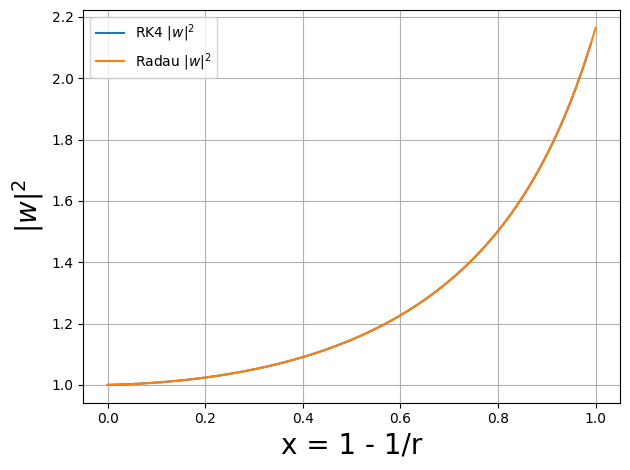

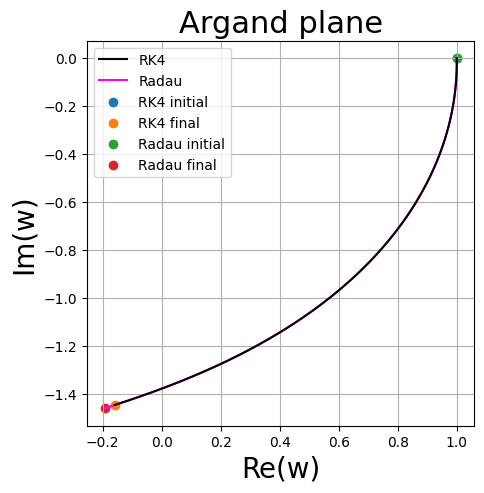

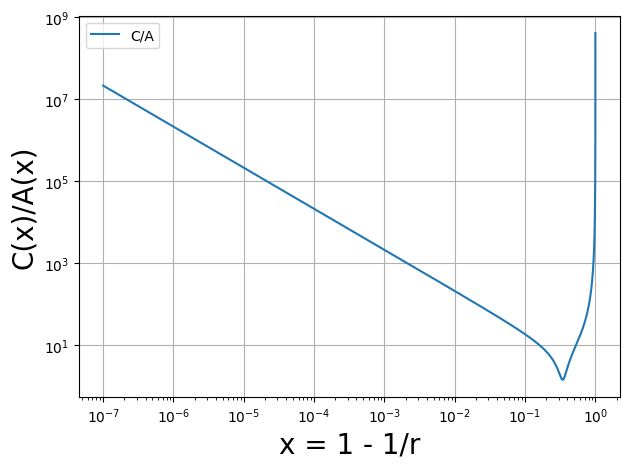

C:\Users\danie\AppData\Local\Temp\ipykernel_22684\20897672.py:94: RuntimeWarning: overflow encountered in exp
  Psi = np.exp(-rho*x_vals_Radau/(1 - x_vals_Radau))*(x_vals_Radau/(1 - x_vals_Radau))**(rho)*(1 - x_vals_Radau)**(-2*rho)*(w_re_Radau + 1j*w_im_Radau)
C:\Users\danie\AppData\Local\Temp\ipykernel_22684\20897672.py:94: RuntimeWarning: invalid value encountered in multiply
  Psi = np.exp(-rho*x_vals_Radau/(1 - x_vals_Radau))*(x_vals_Radau/(1 - x_vals_Radau))**(rho)*(1 - x_vals_Radau)**(-2*rho)*(w_re_Radau + 1j*w_im_Radau)


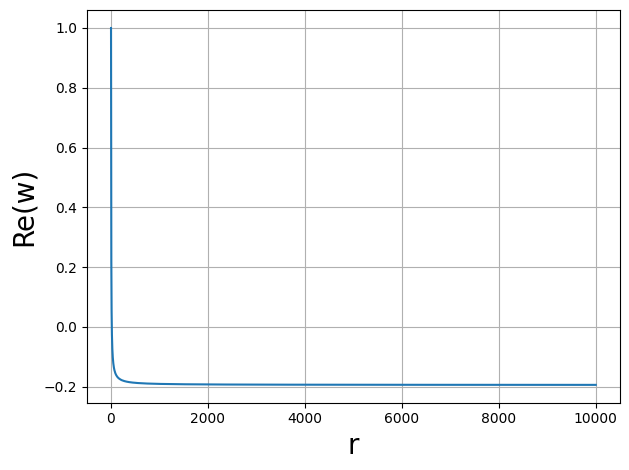

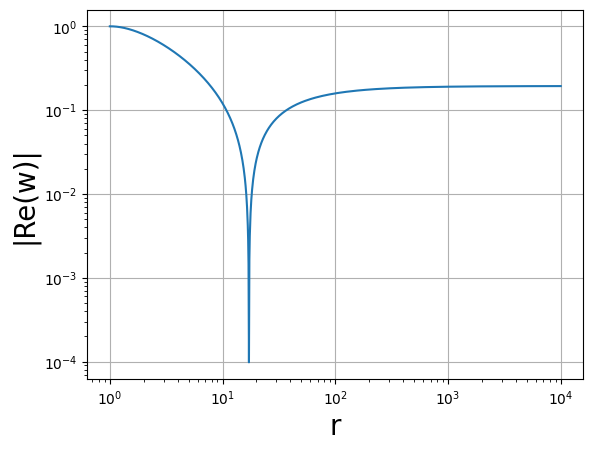

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\ticker.py:2466: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades


OverflowError: cannot convert float infinity to integer

<Figure size 640x480 with 1 Axes>

In [5]:
w_re_RK4 = w_RK4.real
w_im_RK4 = w_RK4.imag
w_re_Radau = w_Radau.real
w_im_Radau = w_Radau.imag

min_idx = np.argmin(-C_full(x_vals_Radau, rho, l)/A_full(x_vals_Radau))
print(x_vals_Radau[min_idx])

def plot(x, y, labels):
    plt.figure()
    plt.plot(x, y, label = labels[1])
    plt.xlabel(labels[0], fontsize = 20)
    plt.ylabel(labels[1], fontsize = 20)
    plt.grid()
    plt.tight_layout()
    plt.show()

plt.figure()
plt.plot(x_vals_RK4, w_re_RK4, label = 'RK4 Re(w)')
plt.plot(x_vals_RK4, w_im_RK4, label = 'RK4 Im(w)')
plt.plot(x_vals_Radau, w_re_Radau, label = 'Radau Re(w)')
plt.plot(x_vals_Radau, w_im_Radau, label = 'Radau Im(w)')
plt.xlabel('x = 1 - 1/r', fontsize = 20)
plt.ylabel('w(x)', fontsize = 20)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_vals_RK4, w_re_RK4, label = 'RK4 Re(w)')
plt.plot(x_vals_RK4, w_im_RK4, label = 'RK4 Im(w)')
plt.plot(x_vals_Radau, w_re_Radau, label = 'Radau Re(w)')
plt.plot(x_vals_Radau, w_im_Radau, label = 'Radau Im(w)')
plt.yscale('log')
plt.xlabel('x = 1 - 1/r', fontsize = 20)
plt.ylabel('w(x)', fontsize = 20)
plt.title('log plot', fontsize = 22)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_vals_RK4, w_RK4, label = 'RK4')
plt.plot(x_vals_Radau, w_Radau, label = 'Radau')
plt.yscale('log')
plt.title('log plot', fontsize = 22)
plt.xlabel('x = 1 - 1/r', fontsize = 20)
plt.ylabel('w(x)', fontsize = 20)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

mag_sq_RK4 = w_re_RK4**2 + w_im_RK4**2
mag_sq_Radau = w_re_Radau**2 + w_im_Radau**2

plt.figure()
plt.plot(x_vals_RK4, mag_sq_RK4, label = r'RK4 $|w|^2$')
plt.plot(x_vals_Radau, mag_sq_Radau, label = r'Radau $|w|^2$')
plt.xlabel('x = 1 - 1/r', fontsize = 20)
plt.ylabel(r'$|w|^2$', fontsize = 20)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

plt.figure(figsize= [5,5])
plt.plot(w_re_RK4, w_im_RK4, color = 'k', zorder = 3, label = 'RK4')
plt.plot(w_re_Radau, w_im_Radau, color = 'magenta', label = 'Radau')
plt.scatter(w_re_RK4[0], w_im_RK4[0], label = 'RK4 initial')
plt.scatter(w_re_RK4[-1], w_im_RK4[-1], label = 'RK4 final')
plt.scatter(w_re_Radau[0], w_im_Radau[0], label = 'Radau initial')
plt.scatter(w_re_Radau[-1], w_im_Radau[-1], label = 'Radau final')
plt.xlabel('Re(w)', fontsize = 20)
plt.ylabel('Im(w)', fontsize = 20)
plt.title('Argand plane', fontsize = 22)
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(x_vals_Radau, np.abs(C_full(x_vals_Radau, rho, l)/A_full(x_vals_Radau)), label = 'C/A')
plt.xlabel('x = 1 - 1/r', fontsize = 20)
plt.ylabel('C(x)/A(x)', fontsize = 20)
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Psi = np.exp(-rho*x_vals_Radau/(1 - x_vals_Radau))*(x_vals_Radau/(1 - x_vals_Radau))**(rho)*(1 - x_vals_Radau)**(-2*rho)*(w_re_Radau + 1j*w_im_Radau)
# plt.plot(x_vals, Psi.real, label = r'Re$(\Psi)$')
# plt.plot(x_vals, Psi.imag, label = r'Im$(\Psi)$')
# plt.xlabel('x = 1 - 1/r', fontsize = 20)
# plt.ylabel(r'$\Psi(x)$', fontsize = 22)
# plt.grid()
# plt.legend()
# plt.tight_layout()
# plt.show()

plot(x_to_r(x_vals_Radau, M = 0.5), w_re_Radau, labels = ['r', 'Re(w)'])

plt.figure()
plt.plot(x_to_r(x_vals_Radau, M = 0.5), np.abs(w_re_Radau))
plt.ylabel('|Re(w)|', fontsize = 20)
plt.xlabel('r', fontsize = 20)
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

plt.figure()
plt.plot(x_to_r(x_vals_Radau, M = 0.5), np.abs(Psi.real))
plt.ylabel('|Psi|', fontsize = 20)
plt.xlabel('r', fontsize = 20)
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

# plt.figure()
# plt.plot(x_vals_Radau, activation_function, label = 'Activation Function')
# plt.plot(x_vals_Radau[1:], dAF, label = 'dy/dx')
# plt.plot(x_vals_Radau[1:-1], d2AF, label = 'd2y/dx2')
# plt.xlabel('x', fontsize = 20)
# plt.legend()
# plt.grid()
# plt.tight_layout()
# plt.show()

Epoch: 1 / 20000. Total scaled loss: 1.8024e+02, 
                    ODE(0) loss: 1.5312e-01, 
                    ODE(1) loss: 3.7605e-01, 
                    Non-trivial solution loss: 1.2732e+00,
                    Physics loss: 1.2102e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 500 / 20000. Total scaled loss: 5.9419e-03, 
                    ODE(0) loss: 3.3266e-10, 
                    ODE(1) loss: 9.6208e-10, 
                    Non-trivial solution loss: 5.4133e-09,
                    Physics loss: 5.9412e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 1000 / 20000. Total scaled loss: 5.7825e-03, 
                    ODE(0) loss: 3.9897e-10, 
                    ODE(1) loss: 3.2160e-09, 
                    Non-trivial solution loss: 5.1146e-09,
      

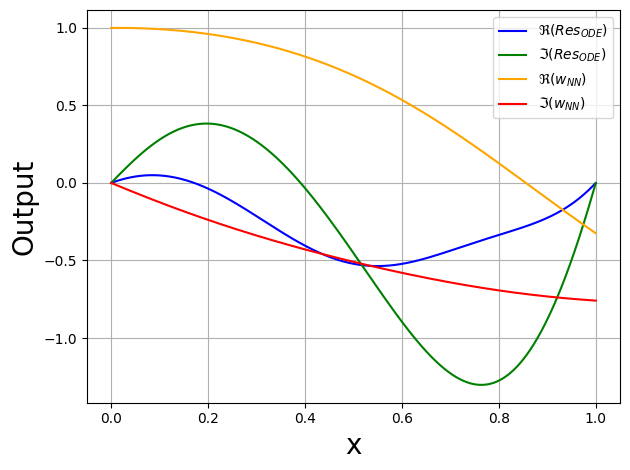

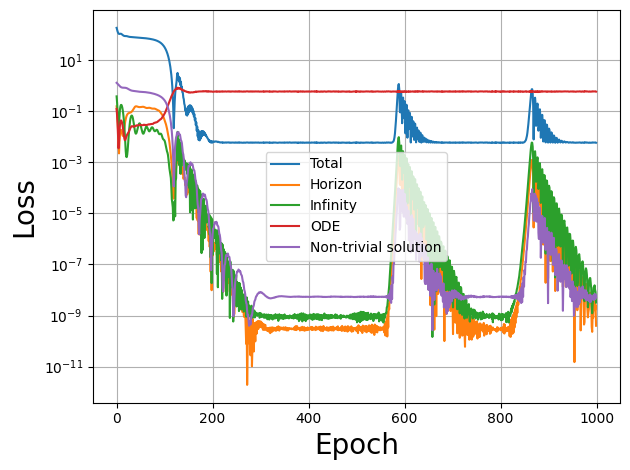

Epoch: 1500 / 20000. Total scaled loss: 7.9329e-03, 
                    ODE(0) loss: 3.9729e-06, 
                    ODE(1) loss: 1.7780e-05, 
                    Non-trivial solution loss: 1.8963e-07,
                    Physics loss: 5.7387e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 2000 / 20000. Total scaled loss: 7.2105e-03, 
                    ODE(0) loss: 3.3118e-06, 
                    ODE(1) loss: 1.0293e-05, 
                    Non-trivial solution loss: 2.2553e-07,
                    Physics loss: 5.8275e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


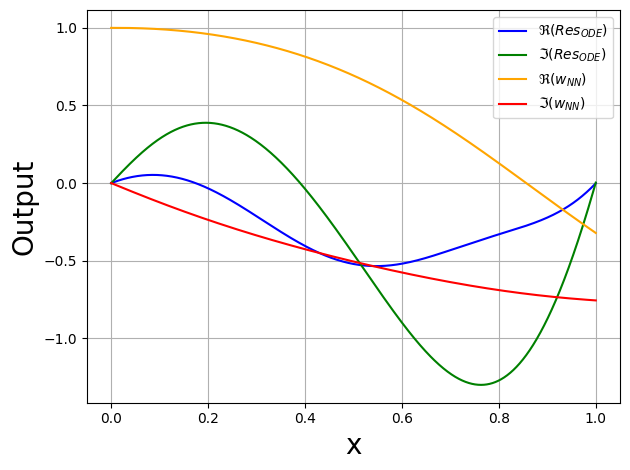

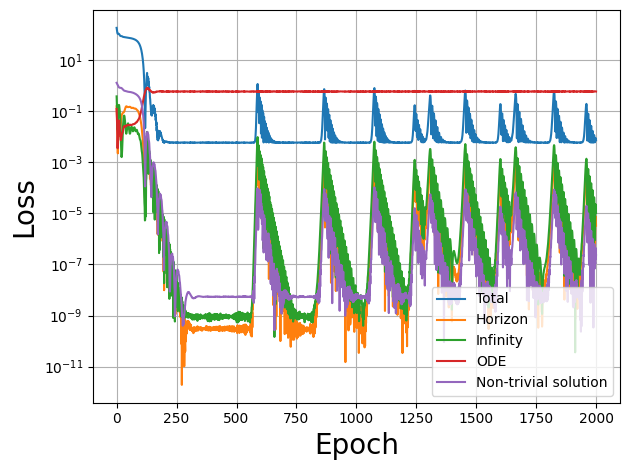

Epoch: 2500 / 20000. Total scaled loss: 5.9126e-03, 
                    ODE(0) loss: 6.0682e-08, 
                    ODE(1) loss: 1.2766e-07, 
                    Non-trivial solution loss: 7.6786e-10,
                    Physics loss: 5.8936e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 3000 / 20000. Total scaled loss: 8.6645e-03, 
                    ODE(0) loss: 4.3054e-06, 
                    ODE(1) loss: 2.3308e-05, 
                    Non-trivial solution loss: 2.1234e-07,
                    Physics loss: 5.8820e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


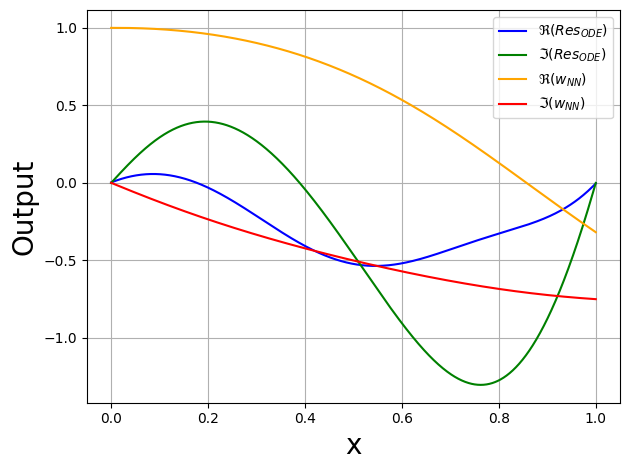

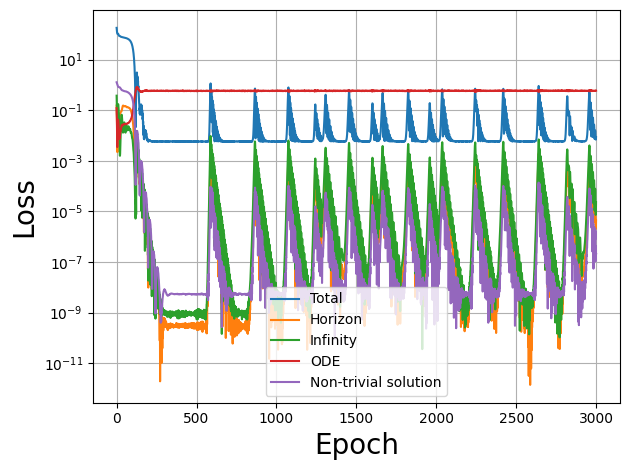

Epoch: 3500 / 20000. Total scaled loss: 1.4205e-01, 
                    ODE(0) loss: 3.2038e-04, 
                    ODE(1) loss: 1.0121e-03, 
                    Non-trivial solution loss: 3.1854e-05,
                    Physics loss: 5.6121e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 4000 / 20000. Total scaled loss: 1.5891e-02, 
                    ODE(0) loss: 2.7579e-05, 
                    ODE(1) loss: 7.1867e-05, 
                    Non-trivial solution loss: 1.3462e-06,
                    Physics loss: 5.8122e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


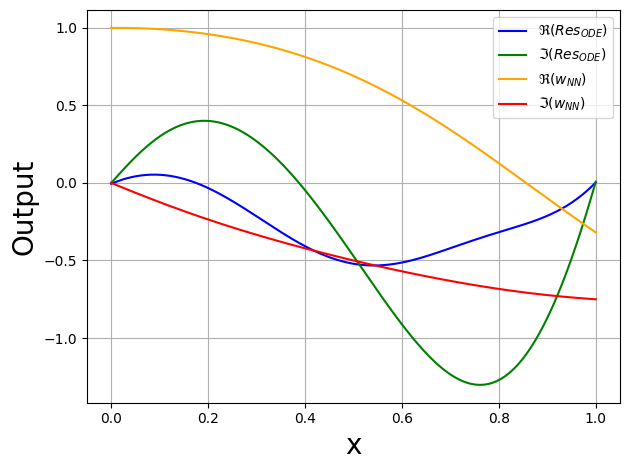

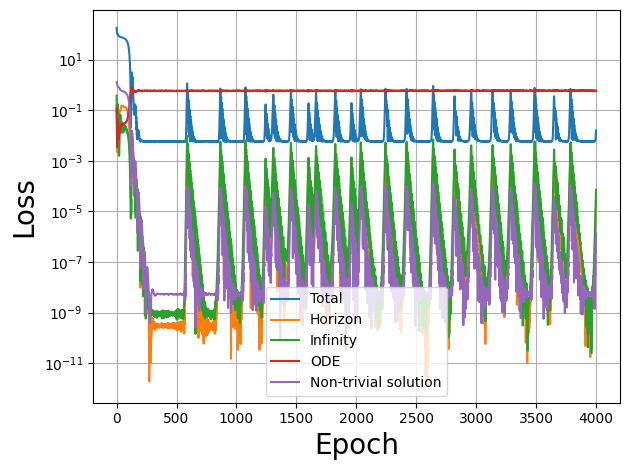

Epoch: 4500 / 20000. Total scaled loss: 8.3229e-02, 
                    ODE(0) loss: 1.4575e-06, 
                    ODE(1) loss: 8.0004e-06, 
                    Non-trivial solution loss: 1.8764e-06,
                    Physics loss: 5.2620e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 5000 / 20000. Total scaled loss: 9.4818e-02, 
                    ODE(0) loss: 2.3175e-07, 
                    ODE(1) loss: 1.7643e-06, 
                    Non-trivial solution loss: 2.3923e-06,
                    Physics loss: 4.4461e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


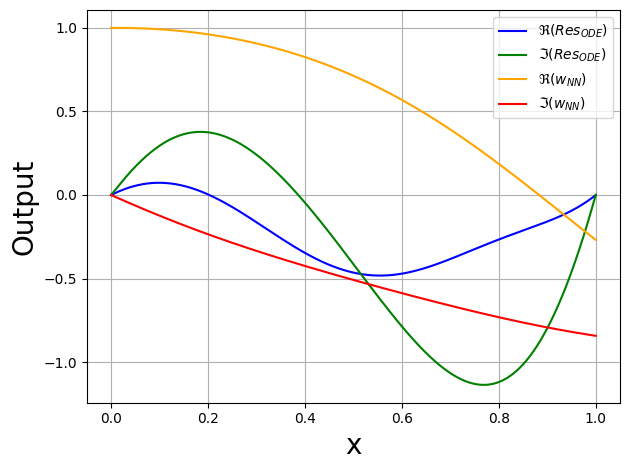

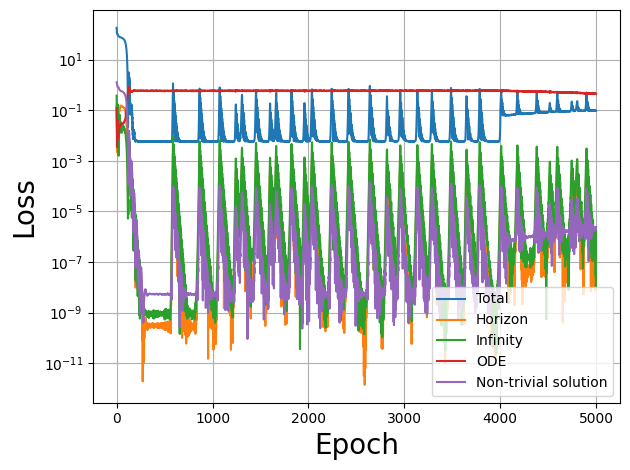

Epoch: 5500 / 20000. Total scaled loss: 1.0530e-01, 
                    ODE(0) loss: 1.0118e-05, 
                    ODE(1) loss: 4.2341e-05, 
                    Non-trivial solution loss: 4.5635e-06,
                    Physics loss: 3.7434e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 6000 / 20000. Total scaled loss: 9.0922e-02, 
                    ODE(0) loss: 1.1804e-07, 
                    ODE(1) loss: 8.7103e-07, 
                    Non-trivial solution loss: 3.2630e-06,
                    Physics loss: 2.7884e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


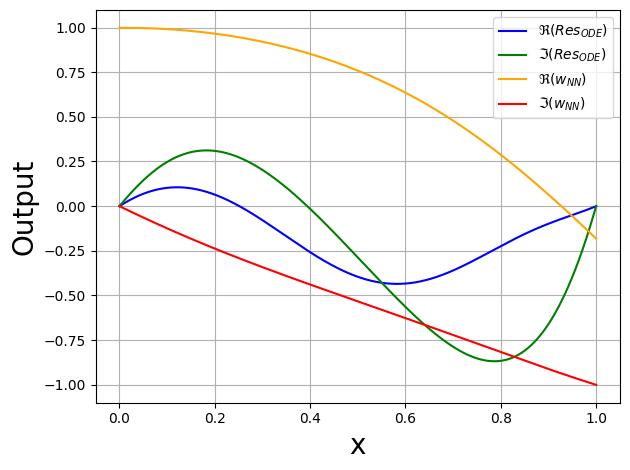

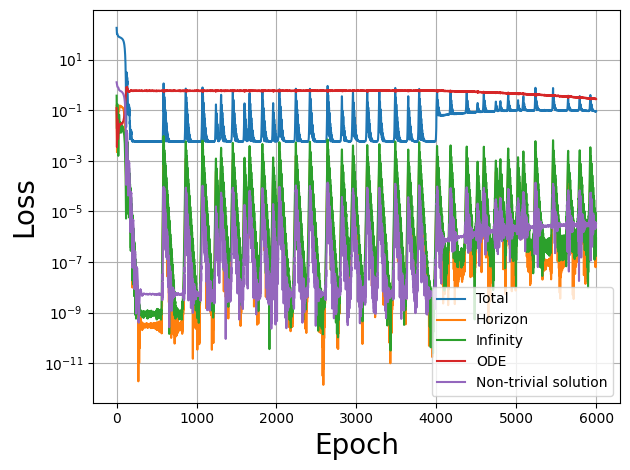

Epoch: 6500 / 20000. Total scaled loss: 1.5736e-01, 
                    ODE(0) loss: 1.5539e-04, 
                    ODE(1) loss: 9.2705e-04, 
                    Non-trivial solution loss: 1.1724e-05,
                    Physics loss: 2.0651e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 7000 / 20000. Total scaled loss: 5.6013e-02, 
                    ODE(0) loss: 9.4874e-07, 
                    ODE(1) loss: 2.6521e-06, 
                    Non-trivial solution loss: 1.8133e-06,
                    Physics loss: 1.2724e-01,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


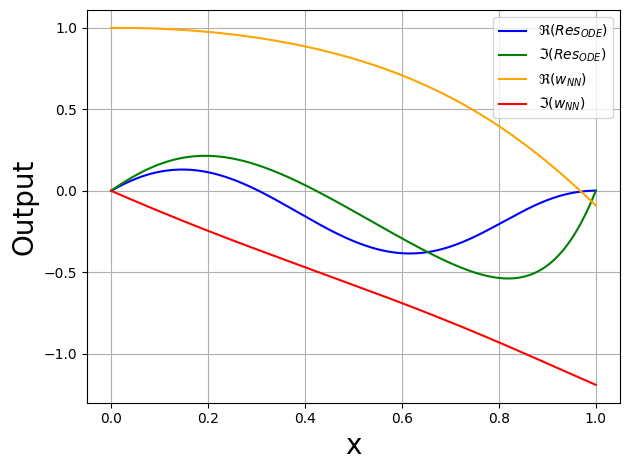

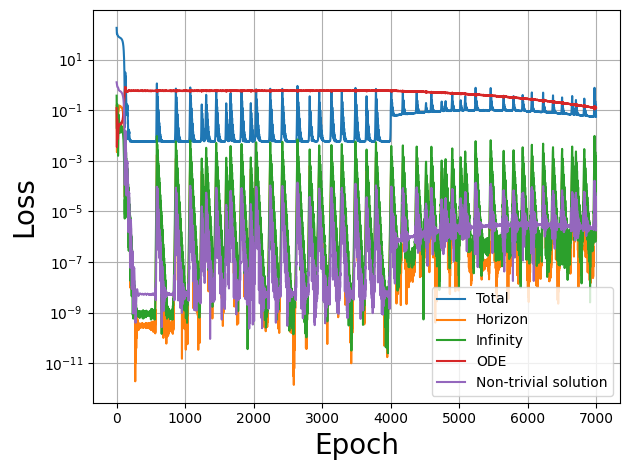

Epoch: 7500 / 20000. Total scaled loss: 3.4419e-02, 
                    ODE(0) loss: 1.8135e-07, 
                    ODE(1) loss: 2.0618e-07, 
                    Non-trivial solution loss: 1.4068e-06,
                    Physics loss: 6.9505e-02,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 8000 / 20000. Total scaled loss: 3.1547e-02, 
                    ODE(0) loss: 1.8276e-05, 
                    ODE(1) loss: 2.0709e-04, 
                    Non-trivial solution loss: 2.4132e-06,
                    Physics loss: 3.4583e-02,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


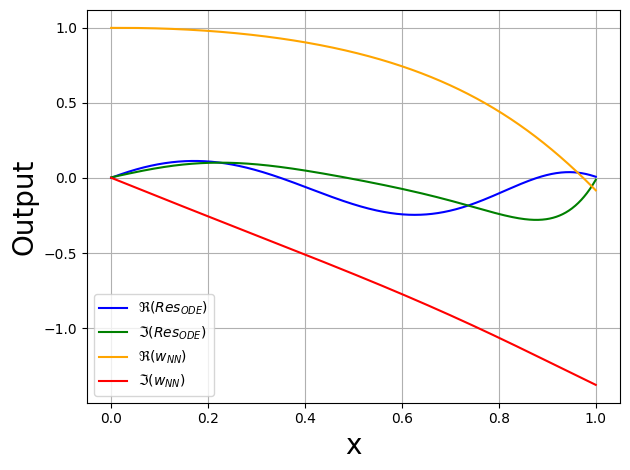

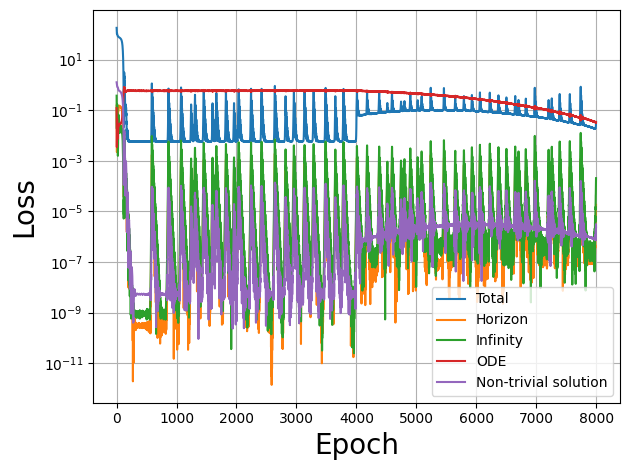

Epoch: 8500 / 20000. Total scaled loss: 8.5090e-03, 
                    ODE(0) loss: 6.2919e-08, 
                    ODE(1) loss: 2.3011e-07, 
                    Non-trivial solution loss: 3.7148e-07,
                    Physics loss: 1.3984e-02,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 9000 / 20000. Total scaled loss: 2.0673e-02, 
                    ODE(0) loss: 3.2084e-05, 
                    ODE(1) loss: 3.1157e-04, 
                    Non-trivial solution loss: 1.7023e-06,
                    Physics loss: 8.3940e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


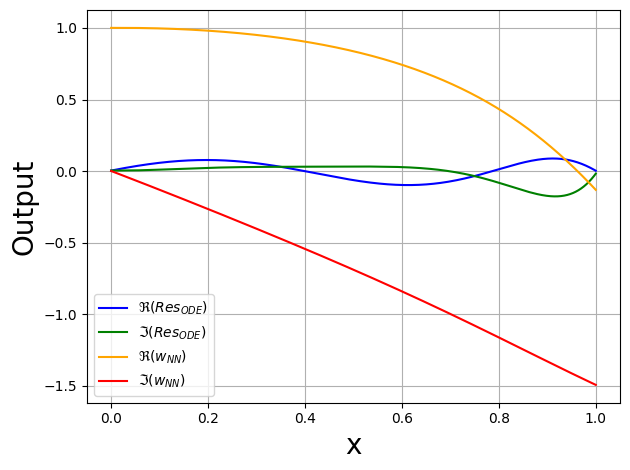

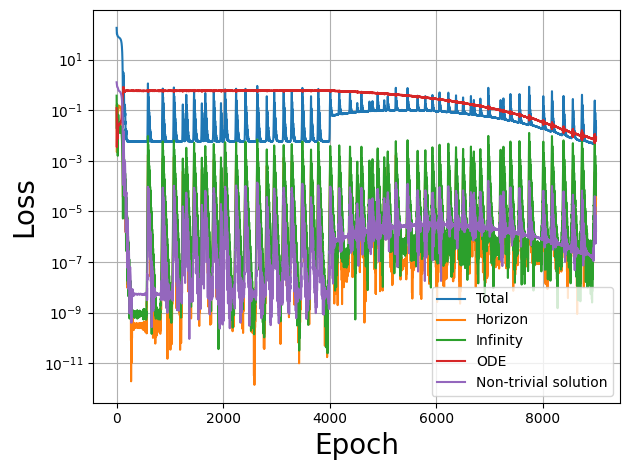

Epoch: 9500 / 20000. Total scaled loss: 9.4724e-03, 
                    ODE(0) loss: 8.8499e-06, 
                    ODE(1) loss: 1.3581e-04, 
                    Non-trivial solution loss: 1.0251e-06,
                    Physics loss: 5.4499e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 10000 / 20000. Total scaled loss: 3.4059e-03, 
                    ODE(0) loss: 8.5629e-07, 
                    ODE(1) loss: 1.0750e-05, 
                    Non-trivial solution loss: 1.3092e-07,
                    Physics loss: 3.9028e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


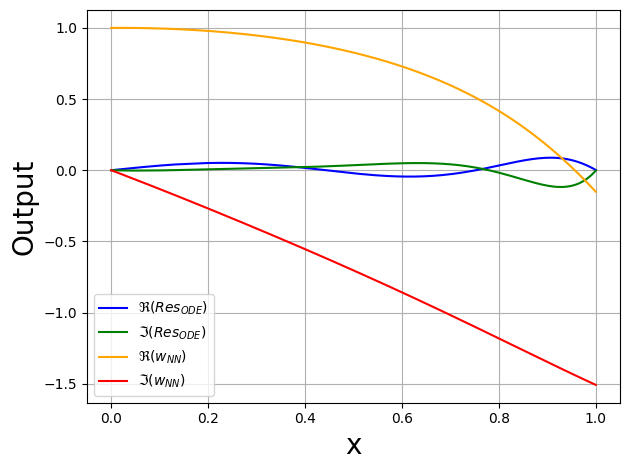

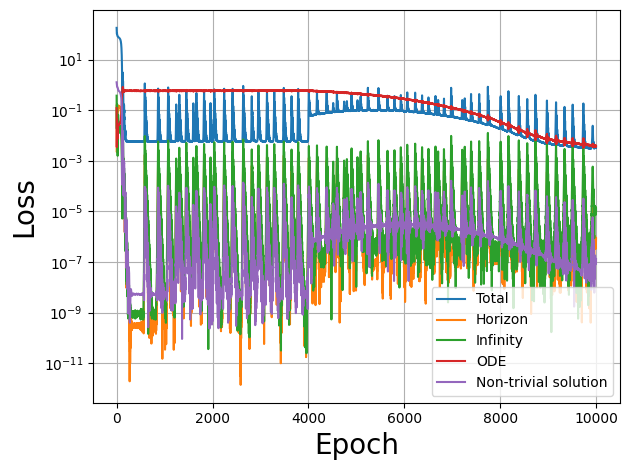

Epoch: 10500 / 20000. Total scaled loss: 3.1910e-03, 
                    ODE(0) loss: 1.4699e-06, 
                    ODE(1) loss: 3.7038e-05, 
                    Non-trivial solution loss: 1.8776e-07,
                    Physics loss: 2.5876e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 11000 / 20000. Total scaled loss: 1.8534e-03, 
                    ODE(0) loss: 4.2383e-07, 
                    ODE(1) loss: 1.6191e-05, 
                    Non-trivial solution loss: 5.5184e-08,
                    Physics loss: 1.6892e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


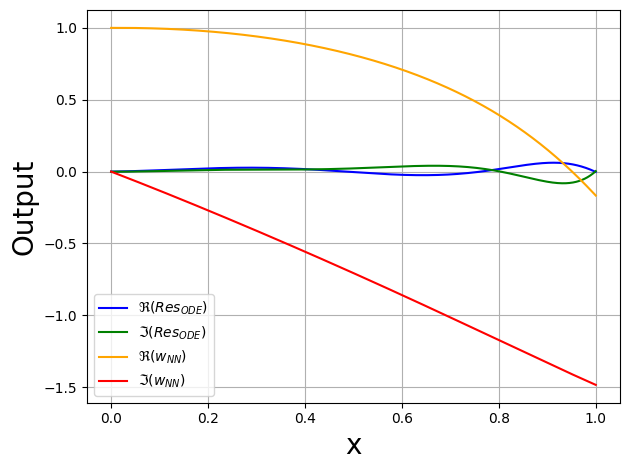

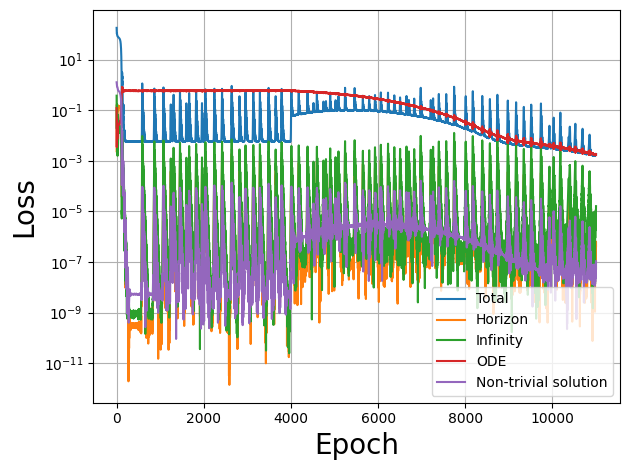

Epoch: 11500 / 20000. Total scaled loss: 1.0423e-03, 
                    ODE(0) loss: 1.2049e-08, 
                    ODE(1) loss: 4.6152e-08, 
                    Non-trivial solution loss: 2.1643e-08,
                    Physics loss: 1.1033e-03,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 12000 / 20000. Total scaled loss: 6.8532e-04, 
                    ODE(0) loss: 3.7822e-08, 
                    ODE(1) loss: 2.8558e-07, 
                    Non-trivial solution loss: 2.5467e-08,
                    Physics loss: 6.8191e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


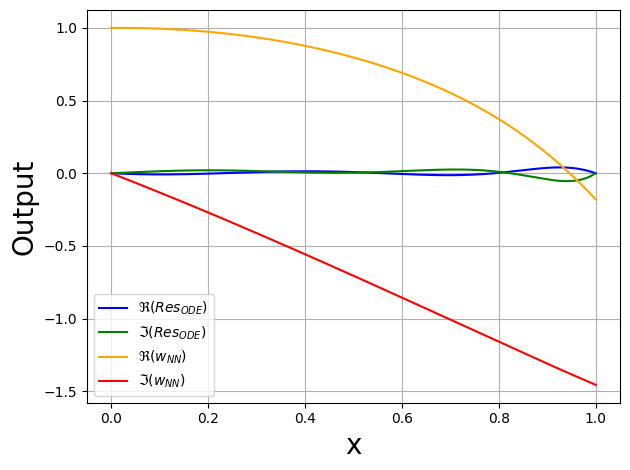

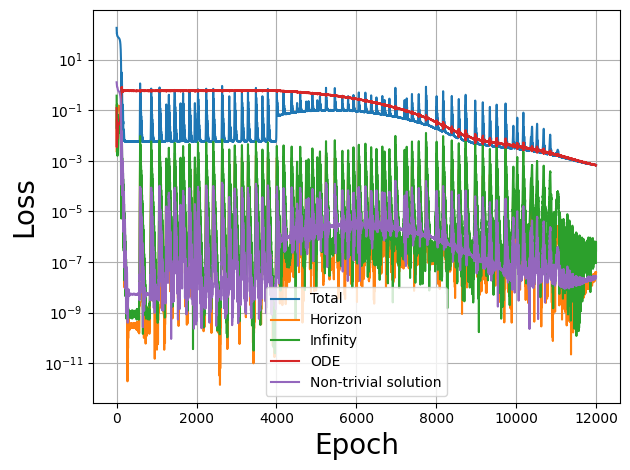

Epoch: 12500 / 20000. Total scaled loss: 5.5281e-02, 
                    ODE(0) loss: 1.9152e-04, 
                    ODE(1) loss: 5.2267e-03, 
                    Non-trivial solution loss: 1.8756e-05,
                    Physics loss: 9.1173e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 13000 / 20000. Total scaled loss: 1.9550e-03, 
                    ODE(0) loss: 7.4031e-06, 
                    ODE(1) loss: 1.1910e-04, 
                    Non-trivial solution loss: 7.1259e-07,
                    Physics loss: 6.8283e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


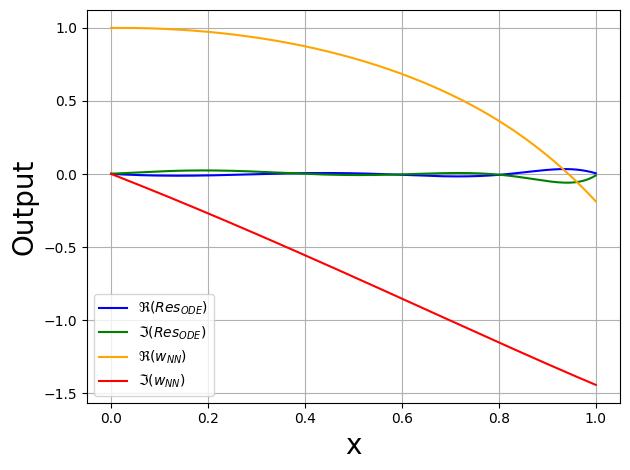

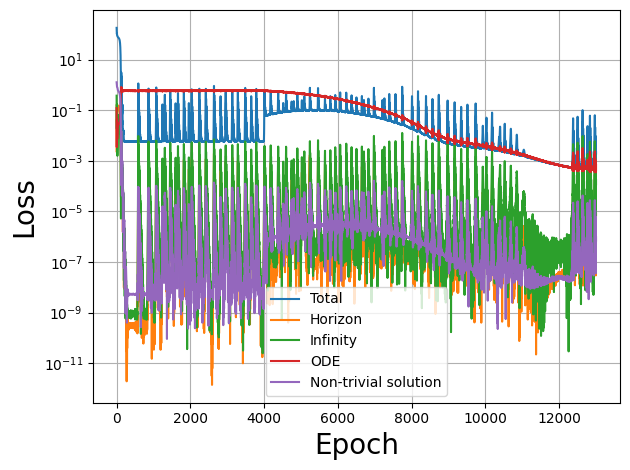

Epoch: 13500 / 20000. Total scaled loss: 3.7062e-03, 
                    ODE(0) loss: 1.7134e-05, 
                    ODE(1) loss: 3.1723e-04, 
                    Non-trivial solution loss: 1.5228e-06,
                    Physics loss: 3.4739e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 14000 / 20000. Total scaled loss: 1.2899e-02, 
                    ODE(0) loss: 6.5297e-05, 
                    ODE(1) loss: 1.1123e-03, 
                    Non-trivial solution loss: 1.3215e-05,
                    Physics loss: 9.9036e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


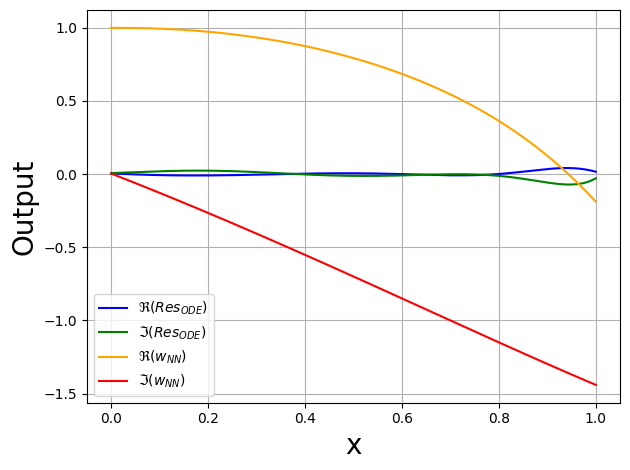

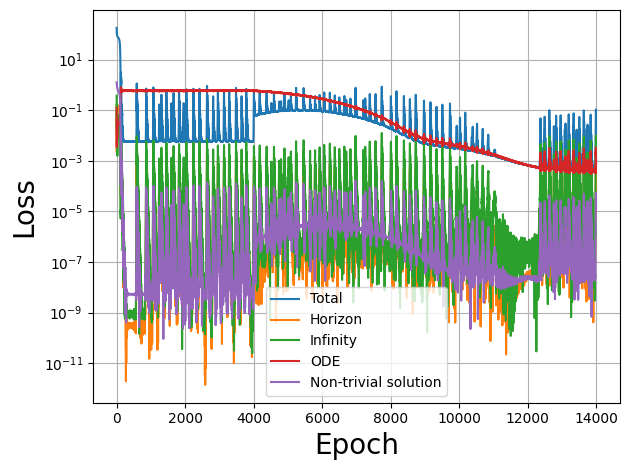

Epoch: 14500 / 20000. Total scaled loss: 9.1443e-04, 
                    ODE(0) loss: 2.6268e-06, 
                    ODE(1) loss: 5.3951e-05, 
                    Non-trivial solution loss: 8.5378e-07,
                    Physics loss: 3.4011e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 15000 / 20000. Total scaled loss: 3.9611e-04, 
                    ODE(0) loss: 3.2294e-07, 
                    ODE(1) loss: 6.6352e-06, 
                    Non-trivial solution loss: 7.5175e-08,
                    Physics loss: 3.2577e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


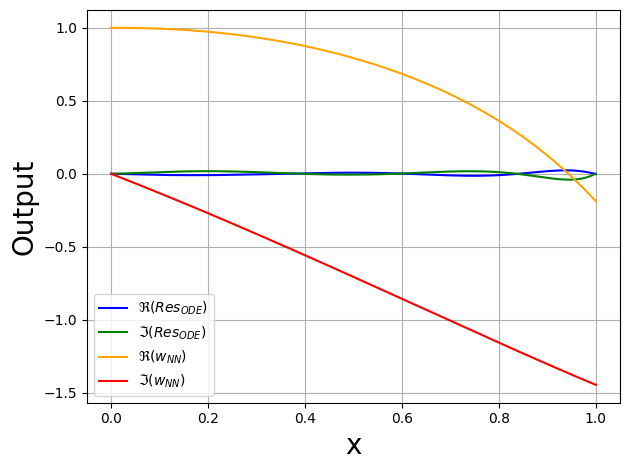

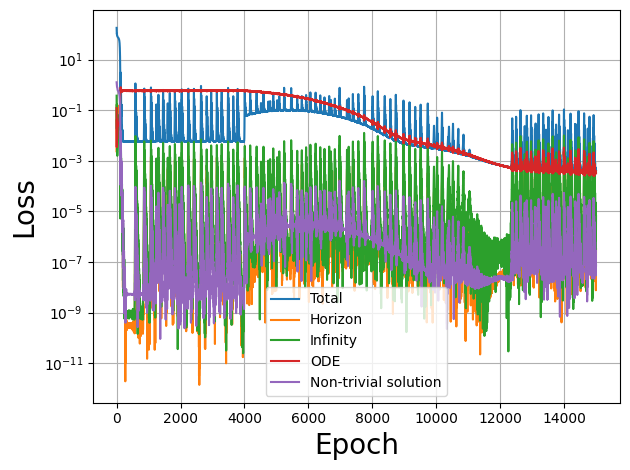

Epoch: 15500 / 20000. Total scaled loss: 3.1452e-04, 
                    ODE(0) loss: 1.8119e-08, 
                    ODE(1) loss: 1.3931e-07, 
                    Non-trivial solution loss: 2.6013e-08,
                    Physics loss: 3.1268e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 16000 / 20000. Total scaled loss: 2.7947e-03, 
                    ODE(0) loss: 1.3874e-05, 
                    ODE(1) loss: 2.1687e-04, 
                    Non-trivial solution loss: 2.3398e-06,
                    Physics loss: 4.6385e-04,
                    Current value of rho: -0.17792 + -0.74734i
                    Target rho: -0.17792 + -0.74734i
------------------------------


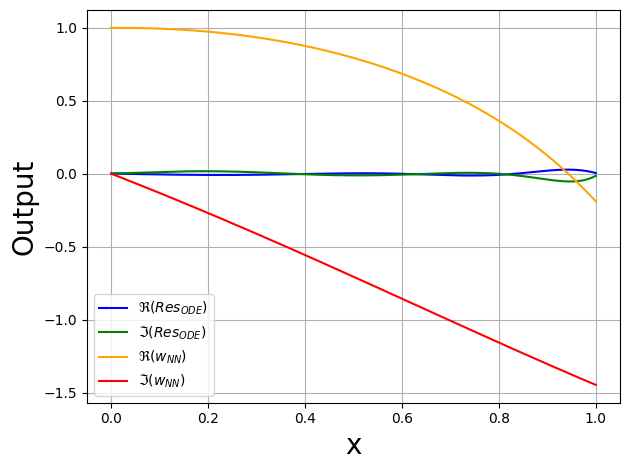

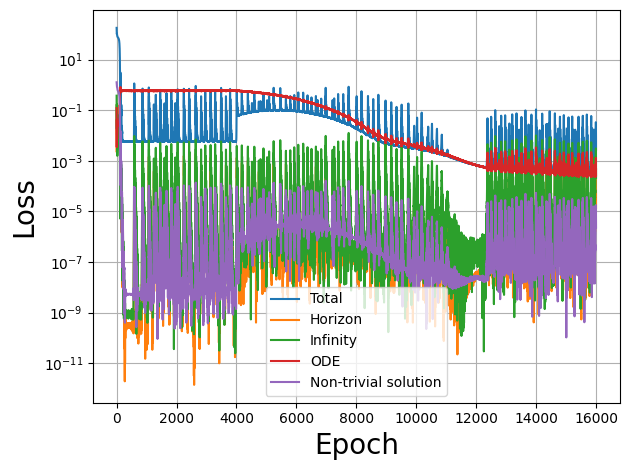

Unfreezing rho...
Epoch: 16500 / 20000. Total scaled loss: 2.7077e-04, 
                    ODE(0) loss: 1.7056e-08, 
                    ODE(1) loss: 5.1667e-07, 
                    Non-trivial solution loss: 2.3837e-08,
                    Physics loss: 2.6519e-04,
                    Current value of rho: -0.17832 + -0.74782i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 17000 / 20000. Total scaled loss: 9.8081e-04, 
                    ODE(0) loss: 3.7464e-06, 
                    ODE(1) loss: 4.7345e-05, 
                    Non-trivial solution loss: 7.0189e-07,
                    Physics loss: 4.6288e-04,
                    Current value of rho: -0.17822 + -0.74783i
                    Target rho: -0.17792 + -0.74734i
------------------------------


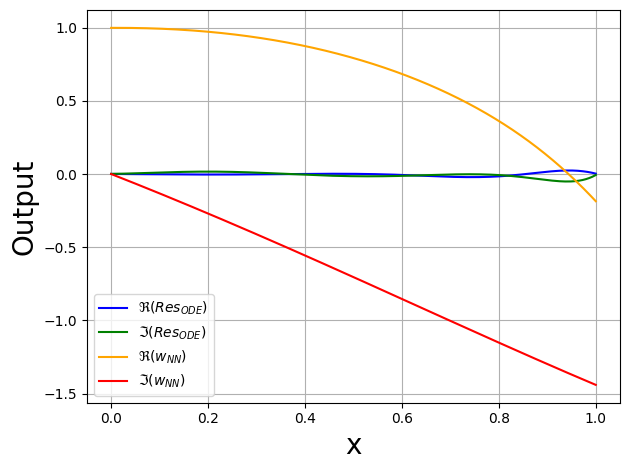

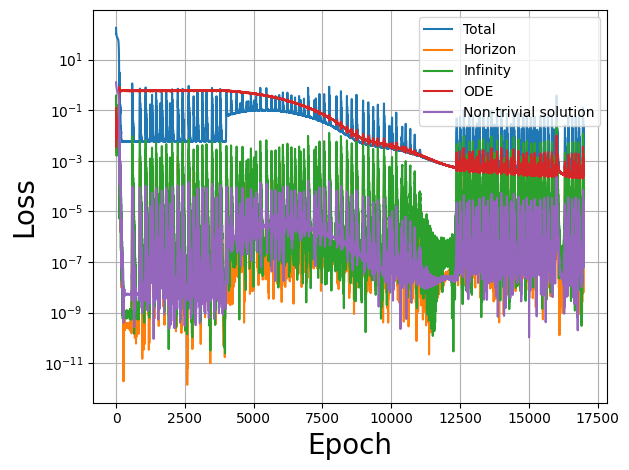

Epoch: 17500 / 20000. Total scaled loss: 2.9903e-03, 
                    ODE(0) loss: 1.5445e-05, 
                    ODE(1) loss: 2.5920e-04, 
                    Non-trivial solution loss: 3.0625e-06,
                    Physics loss: 2.1319e-04,
                    Current value of rho: -0.17832 + -0.74778i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 18000 / 20000. Total scaled loss: 3.0141e-04, 
                    ODE(0) loss: 2.0889e-07, 
                    ODE(1) loss: 4.6886e-06, 
                    Non-trivial solution loss: 5.5042e-08,
                    Physics loss: 2.5189e-04,
                    Current value of rho: -0.17826 + -0.74783i
                    Target rho: -0.17792 + -0.74734i
------------------------------


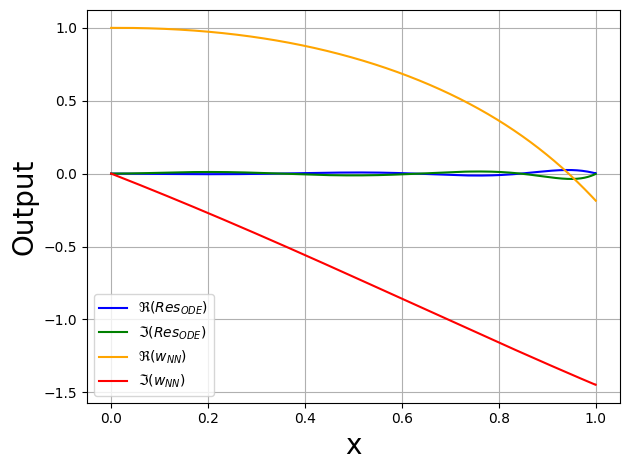

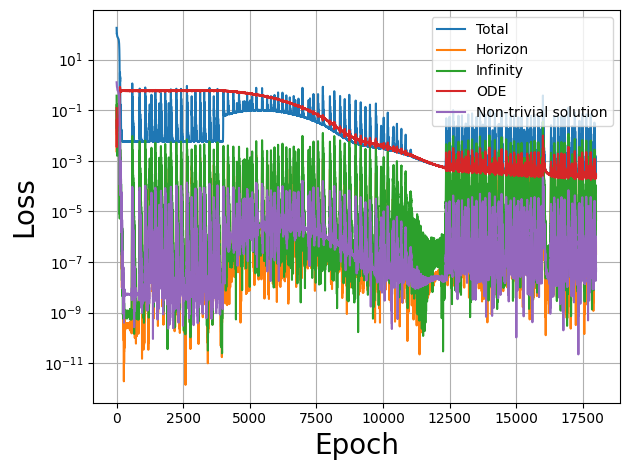

Epoch: 18500 / 20000. Total scaled loss: 6.5493e-04, 
                    ODE(0) loss: 1.5003e-06, 
                    ODE(1) loss: 3.1573e-05, 
                    Non-trivial solution loss: 3.8419e-07,
                    Physics loss: 3.2035e-04,
                    Current value of rho: -0.17822 + -0.74784i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 19000 / 20000. Total scaled loss: 9.7207e-03, 
                    ODE(0) loss: 5.7478e-05, 
                    ODE(1) loss: 8.3192e-04, 
                    Non-trivial solution loss: 7.0644e-06,
                    Physics loss: 7.5616e-04,
                    Current value of rho: -0.17828 + -0.74783i
                    Target rho: -0.17792 + -0.74734i
------------------------------


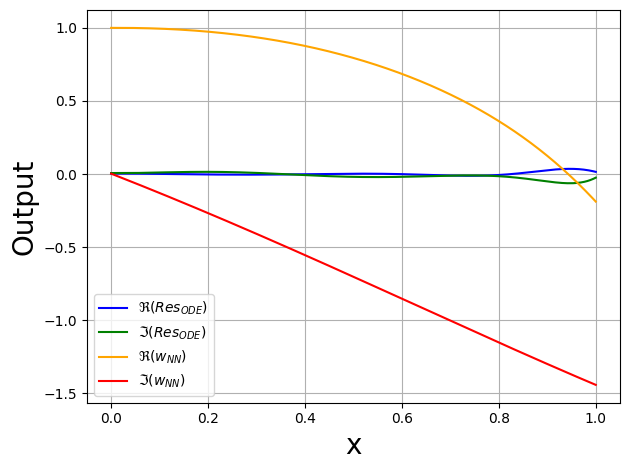

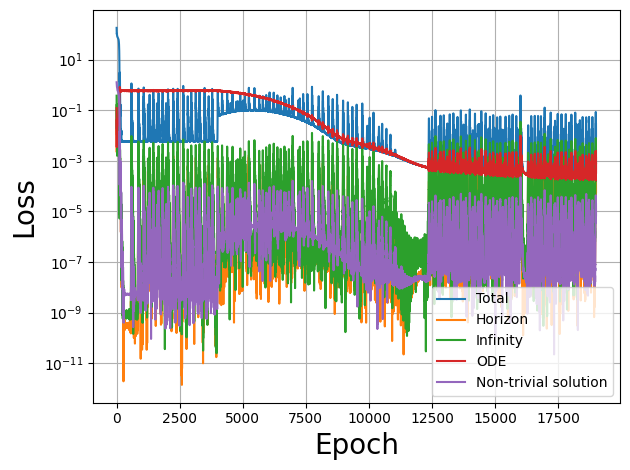

Epoch: 19500 / 20000. Total scaled loss: 1.8622e-02, 
                    ODE(0) loss: 9.7907e-05, 
                    ODE(1) loss: 1.7204e-03, 
                    Non-trivial solution loss: 9.1688e-06,
                    Physics loss: 3.4654e-04,
                    Current value of rho: -0.17813 + -0.74794i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Epoch: 20000 / 20000. Total scaled loss: 2.3202e-04, 
                    ODE(0) loss: 1.7533e-08, 
                    ODE(1) loss: 3.5666e-07, 
                    Non-trivial solution loss: 2.5329e-08,
                    Physics loss: 2.2802e-04,
                    Current value of rho: -0.17800 + -0.74798i
                    Target rho: -0.17792 + -0.74734i
------------------------------


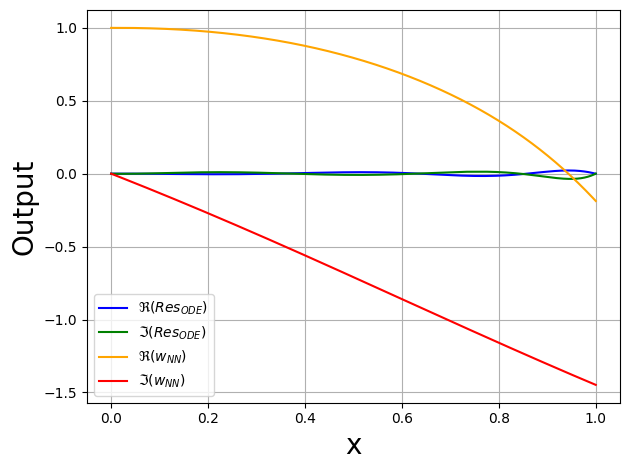

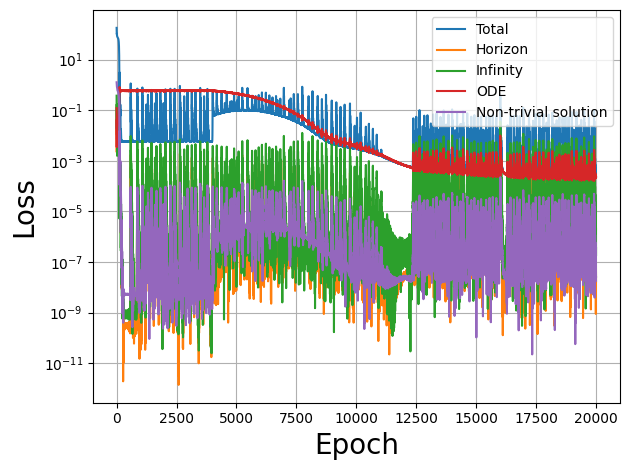

Adam training complete. Switching to L-BFGS:
L-BFGS Epoch: 100 / 1500. Total scaled loss: 1.3280e-06, 
                    ODE(0) loss: 1.3585e-10, 
                    ODE(1) loss: 4.8715e-11, 
                    Non-trivial solution loss: 2.5935e-13,
                    Physics loss: 1.3262e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


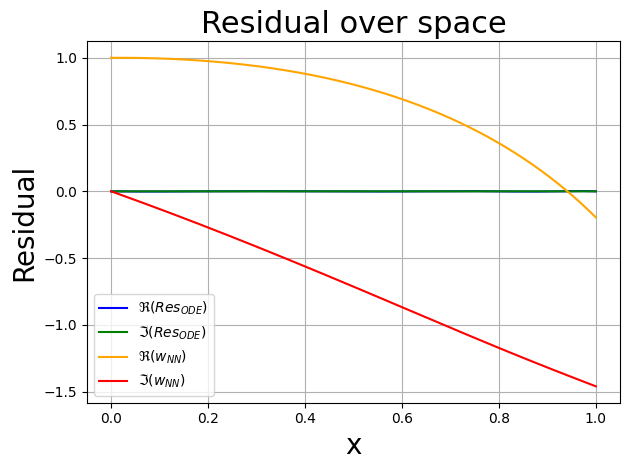

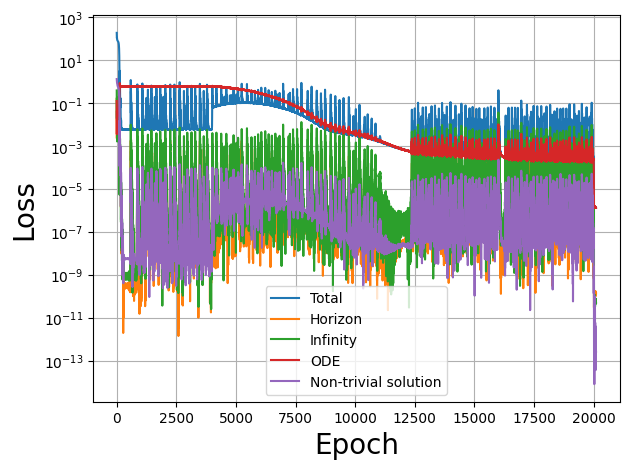

L-BFGS Epoch: 200 / 1500. Total scaled loss: 1.3501e-06, 
                    ODE(0) loss: 1.3488e-10, 
                    ODE(1) loss: 5.2751e-11, 
                    Non-trivial solution loss: 3.2530e-13,
                    Physics loss: 1.3483e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


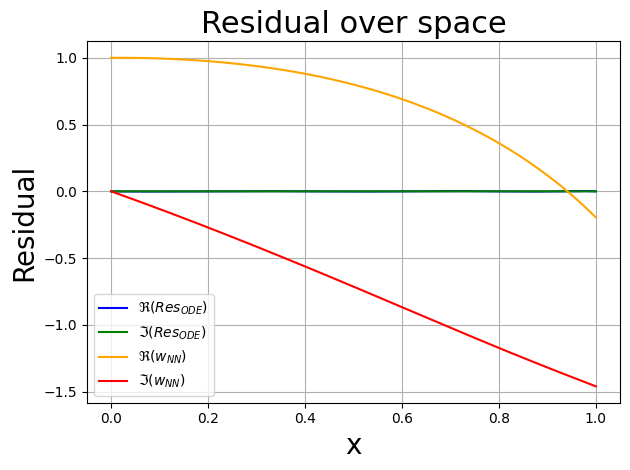

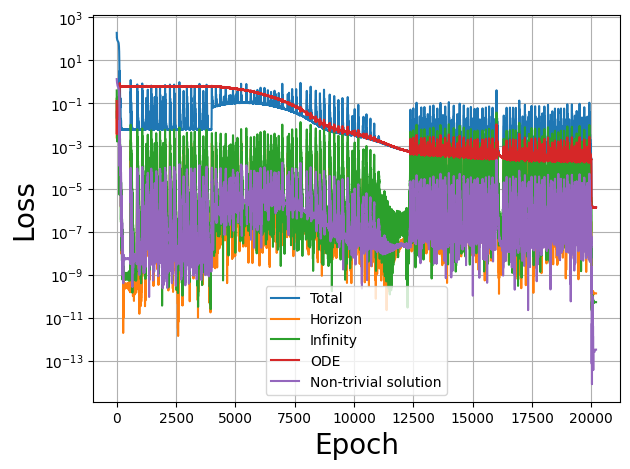

L-BFGS Epoch: 300 / 1500. Total scaled loss: 1.3522e-06, 
                    ODE(0) loss: 1.3488e-10, 
                    ODE(1) loss: 5.2751e-11, 
                    Non-trivial solution loss: 3.2530e-13,
                    Physics loss: 1.3504e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


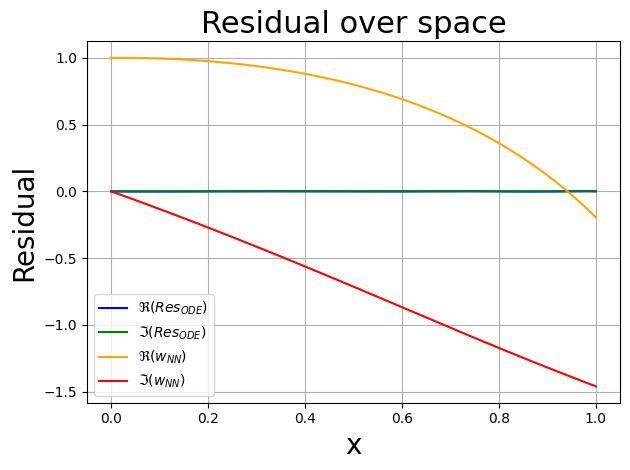

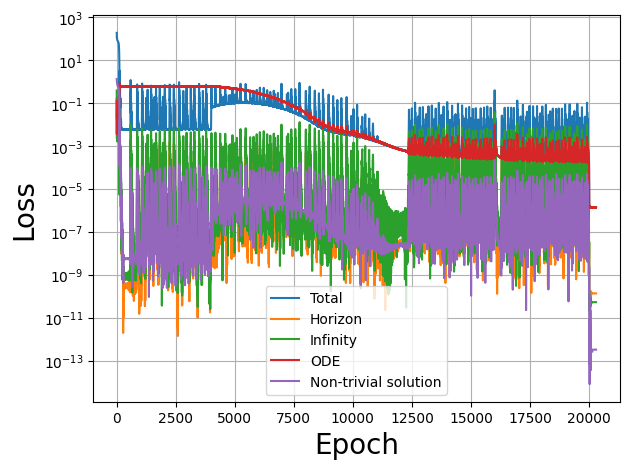

L-BFGS Epoch: 400 / 1500. Total scaled loss: 1.3429e-06, 
                    ODE(0) loss: 1.3488e-10, 
                    ODE(1) loss: 5.2751e-11, 
                    Non-trivial solution loss: 3.2530e-13,
                    Physics loss: 1.3410e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


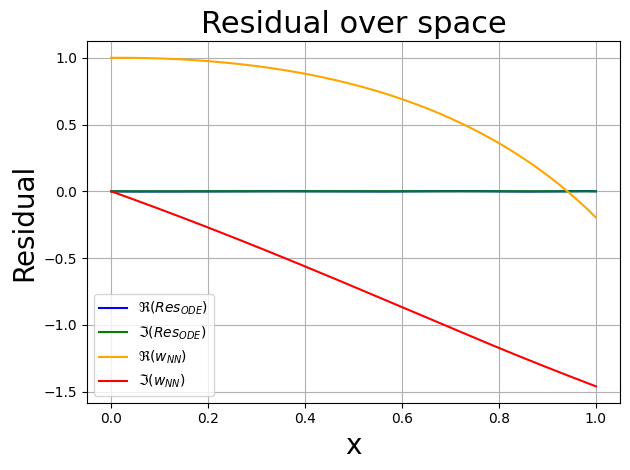

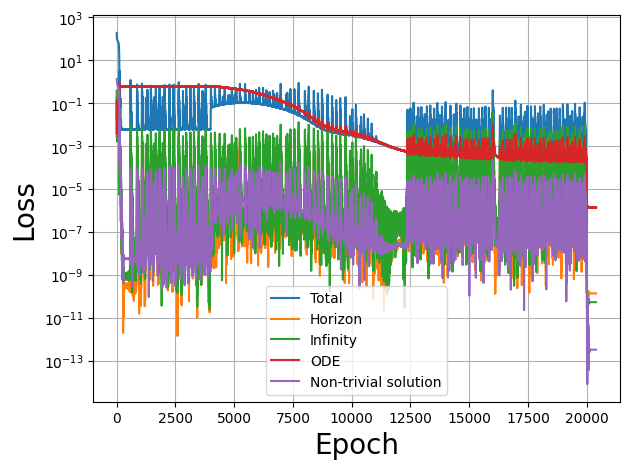

L-BFGS Epoch: 500 / 1500. Total scaled loss: 1.3400e-06, 
                    ODE(0) loss: 1.3488e-10, 
                    ODE(1) loss: 5.2751e-11, 
                    Non-trivial solution loss: 3.2530e-13,
                    Physics loss: 1.3381e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


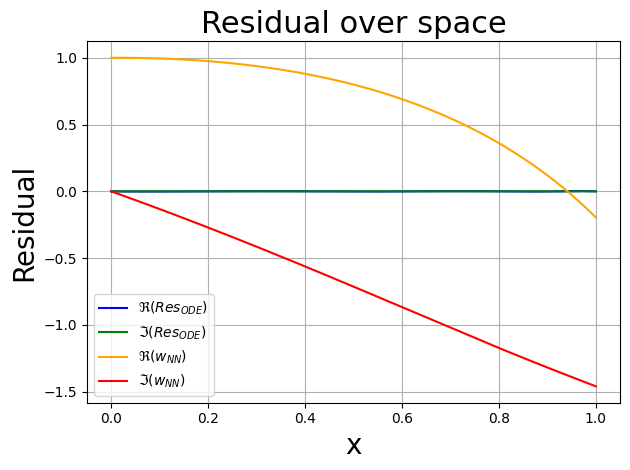

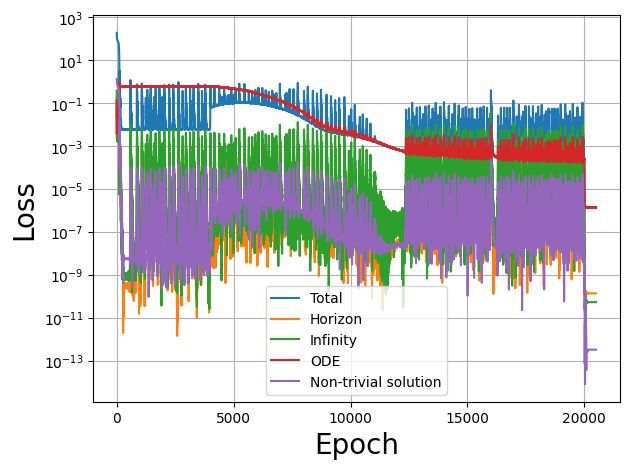

L-BFGS Epoch: 600 / 1500. Total scaled loss: 1.3340e-06, 
                    ODE(0) loss: 1.3104e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.0587e-13,
                    Physics loss: 1.3321e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


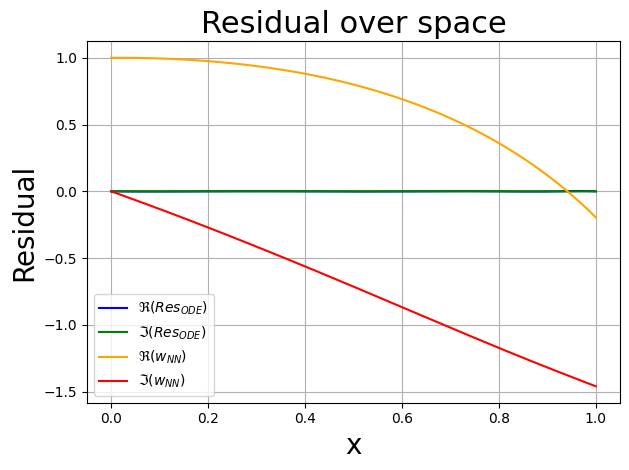

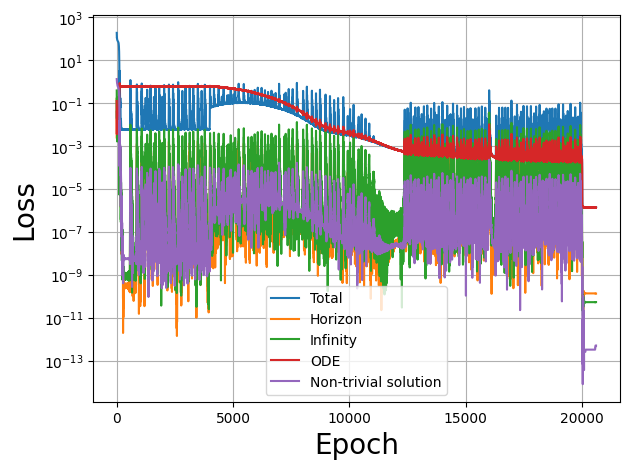

L-BFGS Epoch: 700 / 1500. Total scaled loss: 1.3430e-06, 
                    ODE(0) loss: 1.3104e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.0587e-13,
                    Physics loss: 1.3412e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


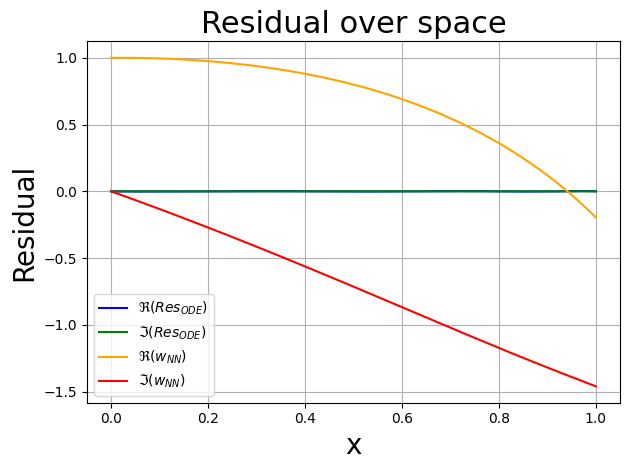

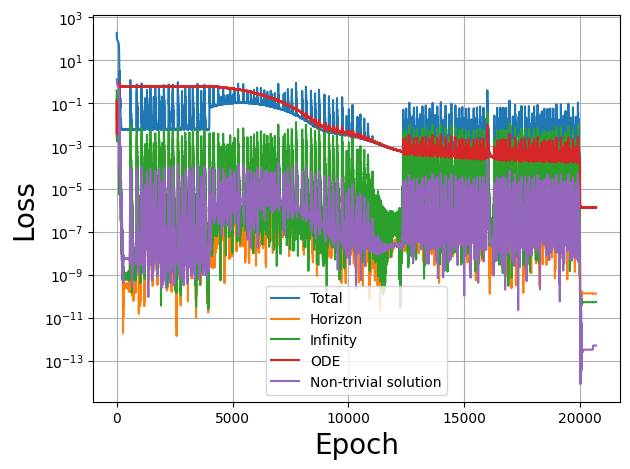

L-BFGS Epoch: 800 / 1500. Total scaled loss: 1.3344e-06, 
                    ODE(0) loss: 1.3104e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.0587e-13,
                    Physics loss: 1.3325e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


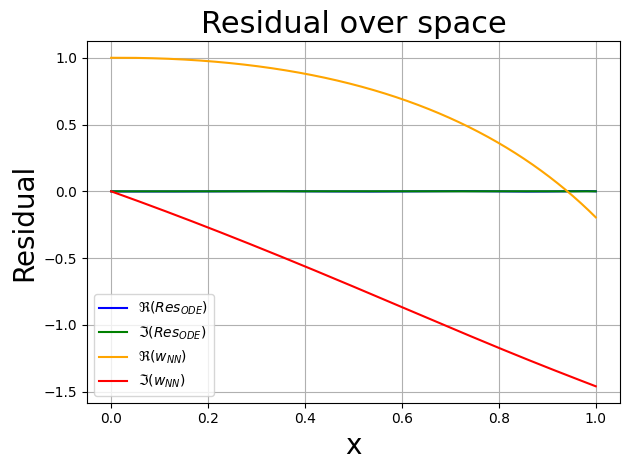

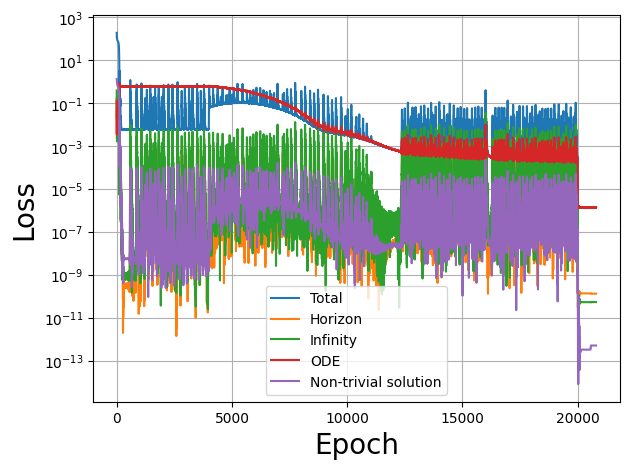

L-BFGS Epoch: 900 / 1500. Total scaled loss: 1.3360e-06, 
                    ODE(0) loss: 1.3104e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.0587e-13,
                    Physics loss: 1.3342e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


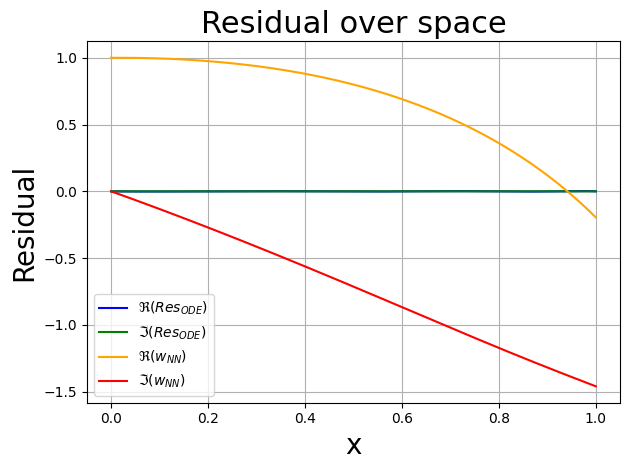

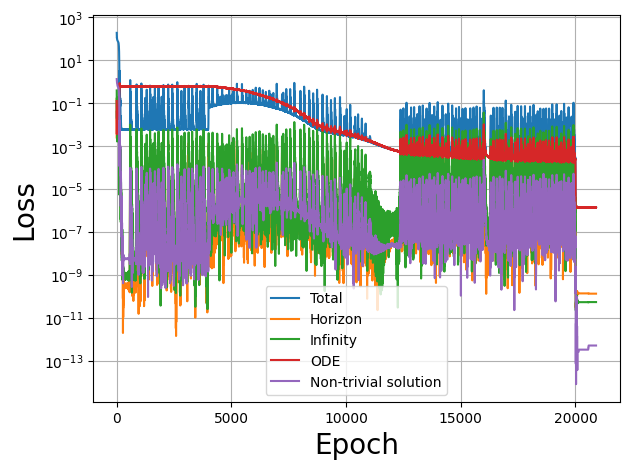

L-BFGS Epoch: 1000 / 1500. Total scaled loss: 1.3377e-06, 
                    ODE(0) loss: 1.3104e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.0587e-13,
                    Physics loss: 1.3358e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


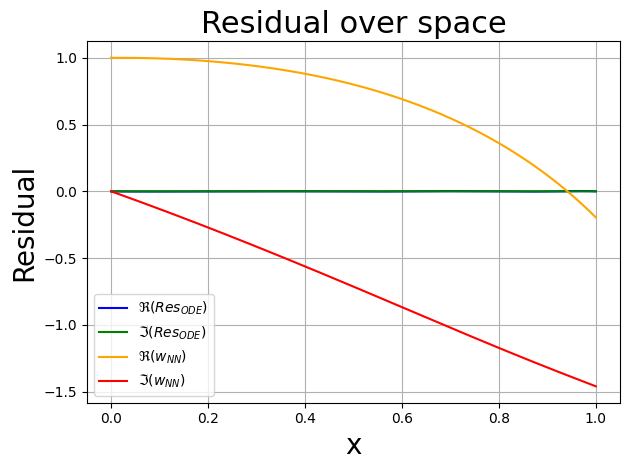

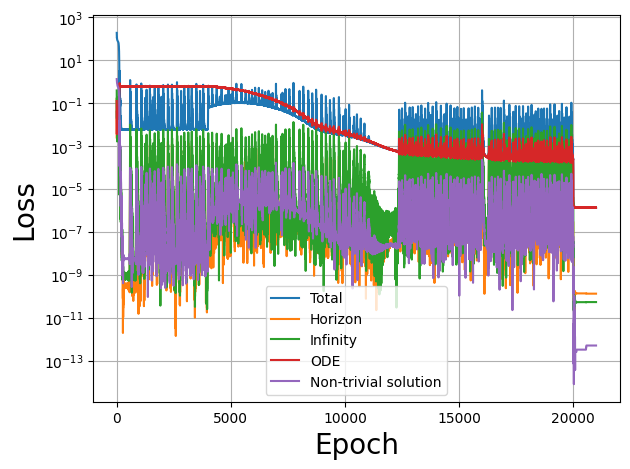

L-BFGS Epoch: 1100 / 1500. Total scaled loss: 1.3398e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3380e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


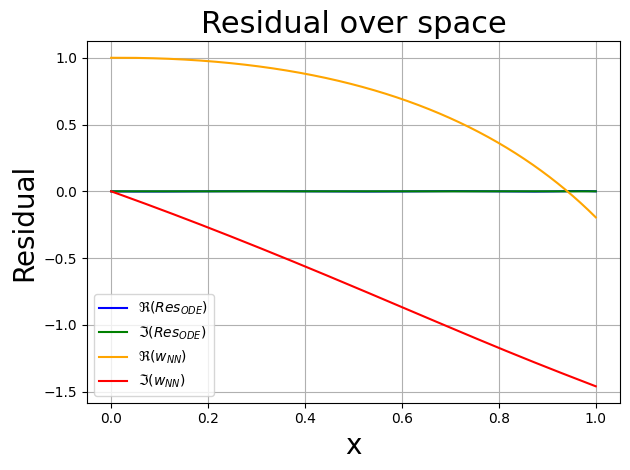

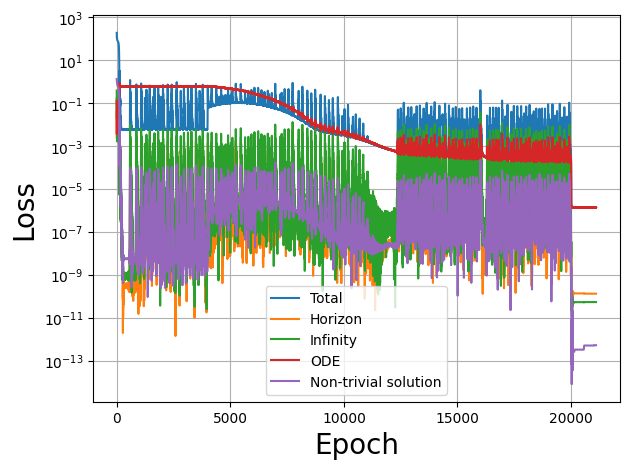

L-BFGS Epoch: 1200 / 1500. Total scaled loss: 1.3146e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3128e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


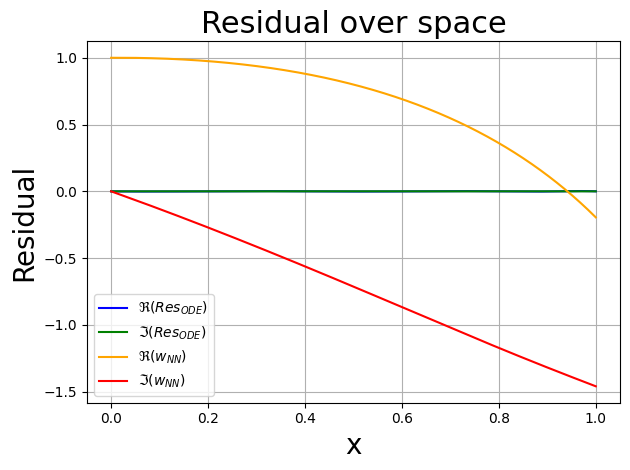

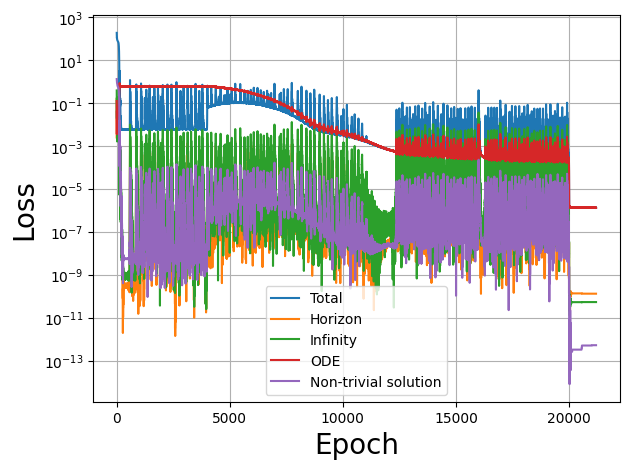

L-BFGS Epoch: 1300 / 1500. Total scaled loss: 1.3352e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3334e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


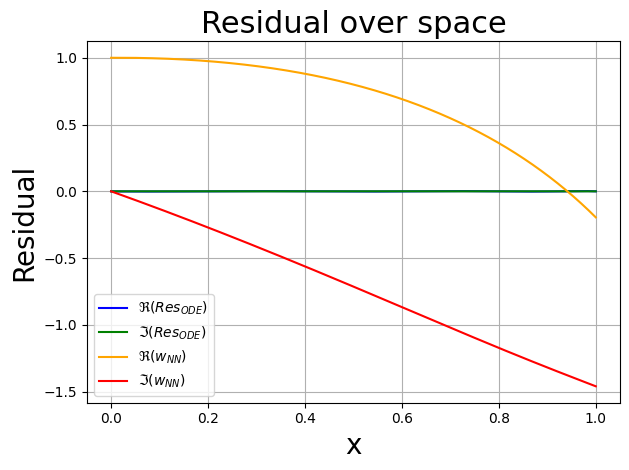

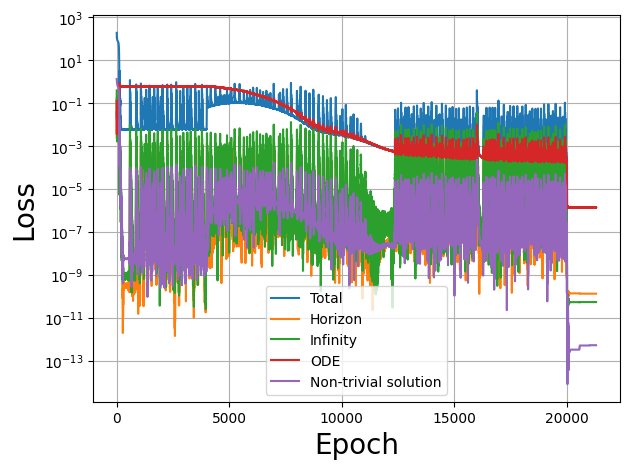

L-BFGS Epoch: 1400 / 1500. Total scaled loss: 1.3205e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3186e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------


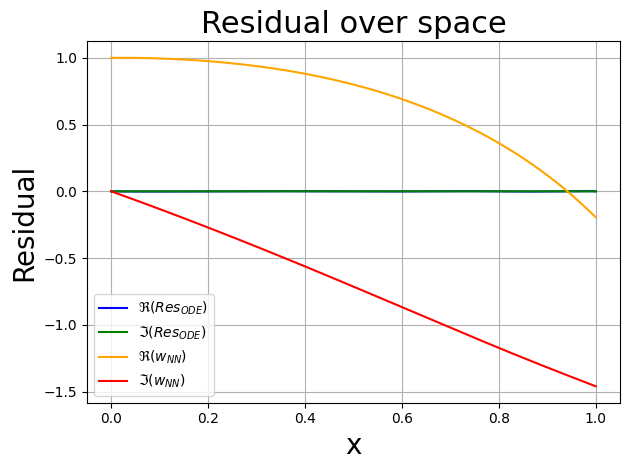

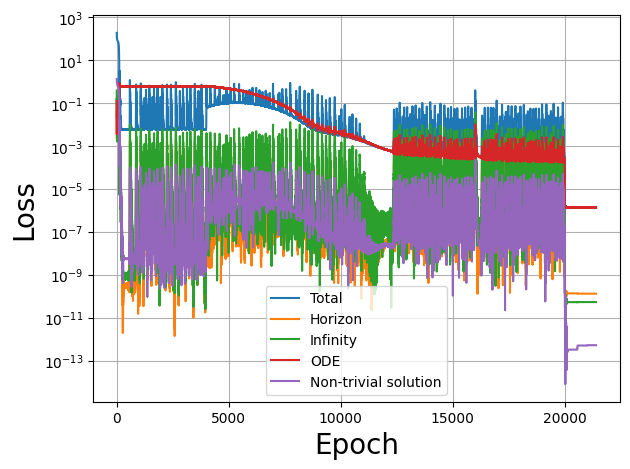

L-BFGS Epoch: 1500 / 1500. Total scaled loss: 1.3133e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3114e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i
------------------------------
Training complete. Total scaled loss: 1.3133e-06, 
                    ODE(0) loss: 1.3065e-10, 
                    ODE(1) loss: 5.3205e-11, 
                    Non-trivial solution loss: 5.2319e-13,
                    Physics loss: 1.3114e-06,
                    Current value of rho: -0.17794 + -0.74727i
                    Target rho: -0.17792 + -0.74734i


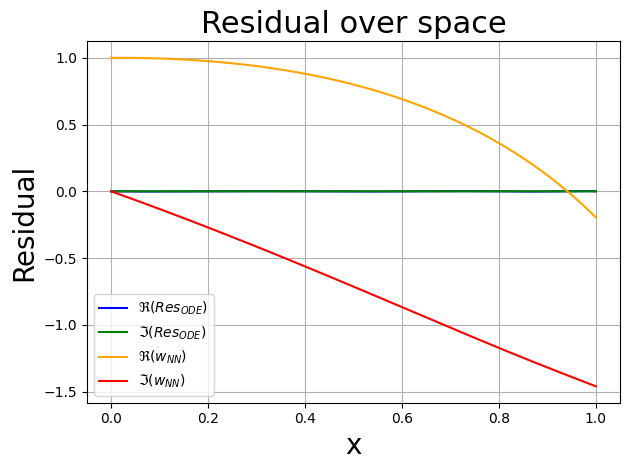

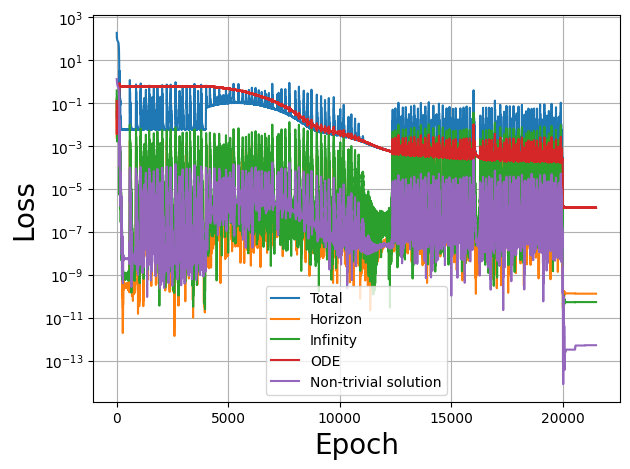

In [13]:
#PINN architecture
class adaptive_tanh(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.beta = nn.Parameter(t.zeros(1, num_features))

    def forward(self, x):
        return (1 + self.beta*x)*t.tanh(x)

class Model(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_hidden_layers=2, rho_init = None):
        super().__init__() 
        self.input_layer = nn.Linear(in_channels, hidden_channels)
        self.act_input = adaptive_tanh(hidden_channels)

        self.hidden_layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        for _ in range(num_hidden_layers):
            self.hidden_layers.append(nn.Linear(hidden_channels, hidden_channels))
            self.activations.append(adaptive_tanh(hidden_channels))

        self.output_layer = nn.Linear(hidden_channels, out_channels) 

        self.rho_re = nn.Parameter(t.tensor(rho_init.real, dtype = DTYPE), requires_grad = False)
        self.rho_im = nn.Parameter(t.tensor(rho_init.imag, dtype = DTYPE), requires_grad = False)

    def forward(self, x: t.tensor):
        x = self.input_layer(x)
        x = self.act_input(x)

        for layer, act in zip(self.hidden_layers, self.activations):
            x = layer(x)
            x = act(x)

        x = self.output_layer(x) 
        return x 

#Set up
DTYPE = t.float32
NP_DTYPE = np.float32 if DTYPE == t.float32 else np.float64
mass = 0.5
mode = 2

#Define functions
def grads(y, x):
        dy = t.autograd.grad(y, x, t.ones_like(y), create_graph = True)[0]
        d2y = t.autograd.grad(dy, x, t.ones_like(dy), create_graph = True)[0]
        return dy, d2y

def first_grad(y, x):
    dy = t.autograd.grad(y, x, t.ones_like(y), create_graph = True)[0]
    return dy

def A(x):
    A = x*(1 - x)**2
    return A

def B(x, rho_re, rho_im, M):
        B_re = (4*rho_re + 3)*x**2 - 4*(2*rho_re + 1)*x + 2*rho_re + 1
        B_im = (4*rho_im)*x**2 - 4*(2*rho_im)*x + 2*rho_im
        return B_re, B_im

def C(x, rho_re, rho_im, M, l):
    C_re = -l*(l + 1) - 3*(x - 1) + 4*rho_re*x - 8*(rho_re**2 - rho_im**2) + \
    4*(rho_re**2 - rho_im**2)*x - 4*rho_re
    C_im = 4*rho_im*x - 16*rho_re*rho_im + 8*rho_re*rho_im*x - 4*rho_im
    return C_re, C_im

def annealing(epoch, total_epochs):
    if epoch <= 0.2*total_epochs:
        BC = 100.0
        NT = 100.0
        ODE = 0.01

    elif 0.2*total_epochs < epoch < 0.6*total_epochs:
        BC = (10.0 - 100.0)/(0.6 - 0.2)*(epoch/total_epochs) + 145
        NT = (10.0 - 100.0)/(0.6 - 0.2)*(epoch/total_epochs) + 145
        ODE = (1.0 - 0.1)/(0.6 - 0.2)*(epoch/total_epochs) - 0.35
    
    elif epoch >= 0.6*total_epochs:
        BC = 10.0
        NT = 10.0
        ODE = 1.0
    
    return [BC, NT, BC, ODE]

def compute_loss(model, x_tensor, weights, mass, mode):
    """weights: [weight_horizon, weight_NT, weight_infinity, weight_ODE]
    returns: Re(w_nn), Im(w_nn) total loss, horizon loss, non-trivial loss, infinity loss, ODE loss, Re(ODE loss), Im(ODE loss)"""

    #Boundary tensors
    x_horizon = t.tensor(0., requires_grad = True, dtype = DTYPE).view(-1, 1)
    x_infinity = t.tensor(1., requires_grad = True, dtype = DTYPE).view(-1, 1) 

    #Horizon loss
    w_h = model(x_horizon)
    w_h_re, w_h_im = w_h[:, 0:1], w_h[:, 1:2]
    dw_h_re = first_grad(w_h_re, x_horizon)
    dw_h_im = first_grad(w_h_im, x_horizon)

    B_h_re, B_h_im = B(x_horizon, model.rho_re, model.rho_im, mass)
    C_h_re, C_h_im = C(x_horizon, model.rho_re, model.rho_im, mass, mode)

    loss_horizon_re = (B_h_re*dw_h_re - B_h_im*dw_h_im +
                        C_h_re*w_h_re - C_h_im*w_h_im)
    loss_horizon_im = (B_h_im*dw_h_re + B_h_re*dw_h_im + 
                    C_h_im*w_h_re + C_h_re*w_h_im)
    loss_horizon = t.mean(loss_horizon_re**2 + loss_horizon_im**2)

    #Non-trivial loss
    loss_nontrivial = t.mean((1.0 - w_h_re)**2 + (0.0 - w_h_im)**2)

    #Infinity loss
    w_inf = model(x_infinity)
    w_inf_re, w_inf_im = w_inf[:, 0:1], w_inf[:, 1:2]
    dw_inf_re = first_grad(w_inf_re, x_infinity)
    dw_inf_im = first_grad(w_inf_im, x_infinity)

    B_inf_re, B_inf_im = B(x_infinity, model.rho_re, model.rho_im, mass)
    C_inf_re, C_inf_im = C(x_infinity, model.rho_re, model.rho_im, mass, mode)

    loss_infinity_re = (B_inf_re*dw_inf_re - B_inf_im*dw_inf_im + 
                        C_inf_re*w_inf_re - C_inf_im*w_inf_im)
    loss_infinity_im = (B_inf_im*dw_inf_re + B_inf_re*dw_inf_im + 
                        C_inf_im*w_inf_re + C_inf_re*w_inf_im)
    loss_infinity = t.mean(loss_infinity_re**2 + loss_infinity_im**2)

    #Physics loss
    w_nn = model(x_tensor)
    w_nn_re, w_nn_im = w_nn[:, 0:1], w_nn[:, 1:2]
    dw_nn_re, d2w_nn_re = grads(w_nn_re, x_tensor)
    dw_nn_im, d2w_nn_im = grads(w_nn_im, x_tensor)

    A_ = A(x_tensor)
    B_re, B_im = B(x_tensor, model.rho_re, model.rho_im, mass)
    C_re, C_im = C(x_tensor, model.rho_re, model.rho_im, mass, mode)

    loss_ode_re = (A_*d2w_nn_re + B_re*dw_nn_re - B_im*dw_nn_im + C_re*w_nn_re - C_im*w_nn_im)
    loss_ode_im = (A_*d2w_nn_im + B_im*dw_nn_re + B_re*dw_nn_im + C_im*w_nn_re + C_re*w_nn_im)
    loss_ode = t.mean(loss_ode_re**2 + loss_ode_im**2)

    total_loss = (weights[0]*loss_horizon + weights[1]*loss_nontrivial + 
                weights[2]*loss_infinity + weights[3]*loss_ode)
    
    return w_nn_re, w_nn_im, total_loss, loss_horizon, loss_nontrivial, loss_infinity, loss_ode, loss_ode_re, loss_ode_im

loss_h = []
loss_nt = []
loss_inf = []
loss_ODE = []

omega = complex(0.74734, -0.177921)
rho = -1j*omega

N_points = 10000
learning_rate = 1e-3
model = Model(1, 2, 32, num_hidden_layers = 3, rho_init = rho).to(dtype = DTYPE)

adam_parameters = [p for p in model.parameters() if p is not model.rho_re and p is not model.rho_im]

optimiser = optim.Adam(adam_parameters, lr = learning_rate)

Adam_iterations = 20000
loss_total = []
rho_real_array = []
rho_imag_array = []
for epoch in range(Adam_iterations):
    optimiser.zero_grad()
    N_uniform = int(0.65*N_points)
    x_uniform = t.rand((N_uniform, 1), dtype = DTYPE)

    N_edges = N_points - N_uniform
    beta_dist = dist.Beta(t.tensor([0.5]), t.tensor([0.5]))
    x_edges = beta_dist.sample((N_edges,)).view(-1, 1).to(DTYPE)

    x_tensor = t.cat([x_uniform, x_edges], dim = 0)
    x_tensor.requires_grad_(True)

    if epoch == int(0.8*Adam_iterations):
        print("Unfreezing rho...")
        model.rho_re.requires_grad = True
        model.rho_im.requires_grad = True
        optimiser.add_param_group({'params': [model.rho_re, model.rho_im], 'lr':1e-3})

    loss_weights = annealing(epoch, Adam_iterations)
    Re_w_nn, Im_w_nn, loss, l_h, l_nt, l_inf, l_ode, l_ode_re, l_ode_im = compute_loss(model, x_tensor, loss_weights, mass, mode)

    loss.backward()
    optimiser.step()

    rho_real_array.append(model.rho_re.item())
    rho_imag_array.append(model.rho_im.item())

    with t.no_grad():
        loss_h.append(l_h.item())
        loss_nt.append(l_nt.item())
        loss_inf.append(l_inf.item())
        loss_ODE.append(l_ode.item())
        loss_total.append(loss.item())

    if (epoch + 1) % 500 == 0 or epoch == 0 or epoch == (Adam_iterations - 1):
        print(f"""Epoch: {epoch + 1} / {Adam_iterations}. Total scaled loss: {loss.item():.4e}, 
                    ODE(0) loss: {l_h.item():.4e}, 
                    ODE(1) loss: {l_inf.item():.4e}, 
                    Non-trivial solution loss: {l_nt.item():.4e},
                    Physics loss: {l_ode.item():.4e},
                    Current value of rho: {model.rho_re.item():.5f} + {model.rho_im.item():.5f}i
                    Target rho: -0.17792 + -0.74734i""")
        print("-"*30)

    if (epoch + 1) % 1000 == 0:
        x_np = x_tensor.detach().numpy().flatten()
        idx = np.argsort(x_np)

        res_re_plot = l_ode_re.detach().numpy().flatten()
        res_im_plot = l_ode_im.detach().numpy().flatten()
        w_re_plot = Re_w_nn.detach().numpy().flatten()
        w_im_plot = Im_w_nn.detach().numpy().flatten()

        plt.figure()
        plt.plot(x_np[idx], res_re_plot[idx], color = 'blue', label = r'$\Re (Res_{ODE})$')
        plt.plot(x_np[idx], res_im_plot[idx], color = 'green', label = r'$\Im (Res_{ODE})$')
        plt.plot(x_np[idx], w_re_plot[idx], color = 'orange', label = r'$\Re (w_{NN})$')
        plt.plot(x_np[idx], w_im_plot[idx], color = 'red', label = r'$\Im (w_{NN})$')
        plt.xlabel('x', fontsize = 20)
        plt.ylabel('Output', fontsize = 20)
        plt.grid()
        plt.legend()
        plt.tight_layout()

        plt.figure()
        plt.plot(loss_total, label = 'Total')
        plt.plot(loss_h, label = 'Horizon')
        plt.plot(loss_inf, label = 'Infinity')
        plt.plot(loss_ODE, label ='ODE')
        plt.plot(loss_nt, label = 'Non-trivial solution')
        plt.yscale('log')
        plt.ylabel('Loss', fontsize = 20)
        plt.xlabel('Epoch', fontsize = 20)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

print("Adam training complete. Switching to L-BFGS:")

model.rho_re.requires_grad = True
model.rho_im.requires_grad = True

lbfgs_optimiser = t.optim.LBFGS(model.parameters(), lr = 1.0, max_iter = 20,
                history_size = 50, line_search_fn = 'strong_wolfe')

lbfgs_iterations = 1500
lbfgs_weights = [10.0, 10.0, 10.0, 1.0]

for epoch in range(lbfgs_iterations):
    N_uniform = int(0.65*N_points)
    x_uniform = t.rand((N_uniform, 1), dtype = DTYPE)

    N_edges = N_points - N_uniform
    beta_dist = dist.Beta(t.tensor([0.5]), t.tensor([0.5]))
    x_edges = beta_dist.sample((N_edges,)).view(-1, 1).to(DTYPE)

    x_tensor = t.cat([x_uniform, x_edges], dim = 0)
    x_tensor.requires_grad_(True)

    info = {'total': 0, 'h': 0, 'nt': 0, 'inf': 0, 'ode':0}
    plot_data = {}
    
    def closure():
        lbfgs_optimiser.zero_grad()

        Re_w_nn, Im_w_nn, loss, l_h, l_nt, l_inf, l_ode, l_ode_re, l_ode_im = compute_loss(model, x_tensor, lbfgs_weights, mass, mode)       
        loss.backward()

        info.update({'total': loss.item(), 'h': l_h.item(), 'nt': l_nt.item(), 'inf': l_inf.item(), 'ode': l_ode.item()})

        plot_data['x'] = x_tensor.detach().numpy()
        plot_data['re_w'] = Re_w_nn.detach().numpy()
        plot_data['im_w'] = Im_w_nn.detach().numpy()
        plot_data['res_re'] = l_ode_re.detach().numpy()
        plot_data['res_im'] = l_ode_im.detach().numpy()

        return loss
    
    lbfgs_optimiser.step(closure)

    loss_h.append(info['h'])
    loss_nt.append(info['nt'])
    loss_inf.append(info['inf'])
    loss_ODE.append(info['ode'])
    loss_total.append(info['total'])

    rho_real_array.append(model.rho_re.item())
    rho_imag_array.append(model.rho_im.item())

    if (epoch + 1) % 100 == 0:
        print(f"""L-BFGS Epoch: {epoch + 1} / {lbfgs_iterations}. Total scaled loss: {info['total']:.4e}, 
                    ODE(0) loss: {info['h']:.4e}, 
                    ODE(1) loss: {info['inf']:.4e}, 
                    Non-trivial solution loss: {info['nt']:.4e},
                    Physics loss: {info['ode']:.4e},
                    Current value of rho: {model.rho_re.item():.5f} + {model.rho_im.item():.5f}i
                    Target rho: -0.17792 + -0.74734i""")
        print("-"*30)

    if epoch == (lbfgs_iterations - 1):
        print(f"""Training complete. Total scaled loss: {info['total']:.4e}, 
                    ODE(0) loss: {info['h']:.4e}, 
                    ODE(1) loss: {info['inf']:.4e}, 
                    Non-trivial solution loss: {info['nt']:.4e},
                    Physics loss: {info['ode']:.4e},
                    Current value of rho: {model.rho_re.item():.5f} + {model.rho_im.item():.5f}i
                    Target rho: -0.17792 + -0.74734i""")

    if (epoch + 1) % 100 == 0 or epoch == (lbfgs_iterations - 1):
        x_plot = plot_data['x'].flatten()
        idx = np.argsort(x_plot)

        plt.figure()
        plt.plot(x_plot[idx], plot_data['res_re'].flatten()[idx], color = 'blue', label = r'$\Re (Res_{ODE})$')
        plt.plot(x_plot[idx], plot_data['res_im'].flatten()[idx], color = 'green', label = r'$\Im (Res_{ODE})$')
        plt.plot(x_plot[idx], plot_data['re_w'].flatten()[idx], color = 'orange', label = r'$\Re (w_{NN})$')
        plt.plot(x_plot[idx], plot_data['im_w'].flatten()[idx], color = 'red', label = r'$\Im (w_{NN})$')
        plt.xlabel('x', fontsize = 20)
        plt.ylabel('Residual', fontsize = 20)
        plt.title('Residual over space', fontsize = 22)
        plt.grid()
        plt.legend()
        plt.tight_layout()
        
        plt.figure()
        plt.plot(loss_total, label = 'Total')
        plt.plot(loss_h, label = 'Horizon')
        plt.plot(loss_inf, label = 'Infinity')
        plt.plot(loss_ODE, label ='ODE')
        plt.plot(loss_nt, label = 'Non-trivial solution')
        plt.yscale('log')
        plt.ylabel('Loss', fontsize = 20)
        plt.xlabel('Epoch', fontsize = 20)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()
        
losses = np.array([loss_h, loss_nt, loss_inf, loss_ODE, loss_total])
rho_real_array = np.array(rho_real_array)
rho_imag_array = np.array(rho_imag_array)

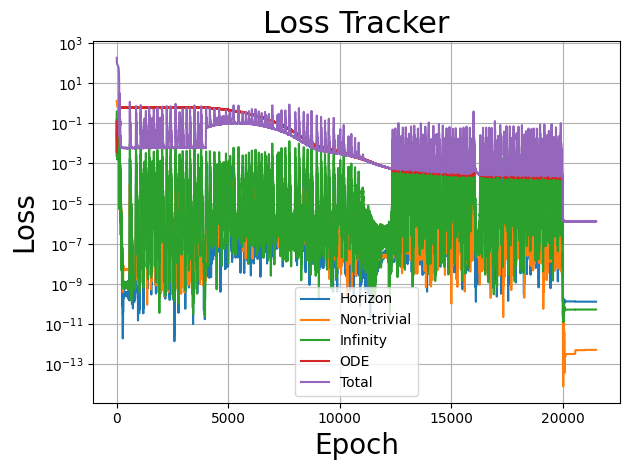

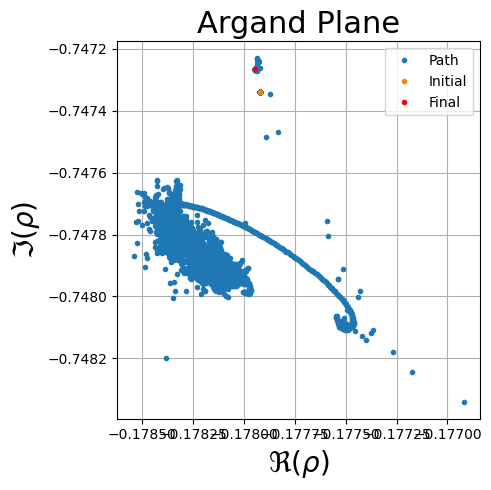

NameError: name 'loss_ode_re' is not defined

<Figure size 640x480 with 0 Axes>

In [35]:
labels = ['Horizon', 'Non-trivial', 'Infinity', 'ODE', 'Total']
rho_real_array = rho_real_array.flatten()
rho_imag_array = rho_imag_array.flatten()
x_np2 = x_tensor.detach().numpy()

plt.figure()
for i, l in enumerate(losses):
    plt.plot(range(Adam_iterations + lbfgs_iterations), l, label = labels[i])
plt.yscale('log')
plt.xlabel('Epoch', fontsize = 20)
plt.ylabel('Loss', fontsize = 20)
plt.title('Loss Tracker', fontsize = 22)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#NOW PLOT ODE RESIDUAL AND RHO WALK AROUND COMPLEX PLANE
plt.figure(figsize = [5,5])
plt.plot(rho_real_array, rho_imag_array, '.', label = 'Path')
plt.plot(rho_real_array[0], rho_imag_array[0], '.', label = 'Initial')
plt.plot(rho_real_array[-1], rho_imag_array[-1], '.', color = 'red', label = 'Final')
plt.xlabel(r'$\Re (\rho)$', fontsize = 20)
plt.ylabel(r'$\Im (\rho)$', fontsize = 20)
plt.title('Argand Plane', fontsize = 22)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# loss_ode_re = loss_ode_re.detach().numpy()
# loss_ode_re = loss_ode_re.flatten()
# loss_ode_im = loss_ode_im.detach().numpy()
# loss_ode_im = loss_ode_im.flatten()

plt.figure()
plt.plot(x_np, loss_ode_re, color = 'blue', label = r'$\Re (Res_{ODE})$')
plt.plot(x_np, loss_ode_im, color = 'green', label = r'$\Im (Res_{ODE})$')
plt.xlabel('x', fontsize = 20)
plt.ylabel('Residual', fontsize = 20)
plt.title('Residual over space', fontsize = 22)
# plt.yscale('log')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

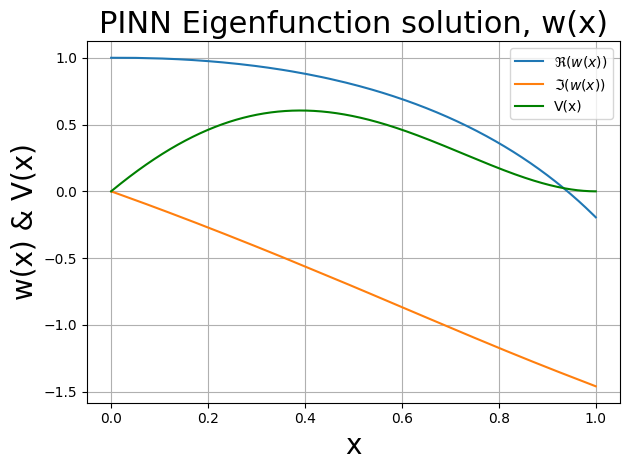

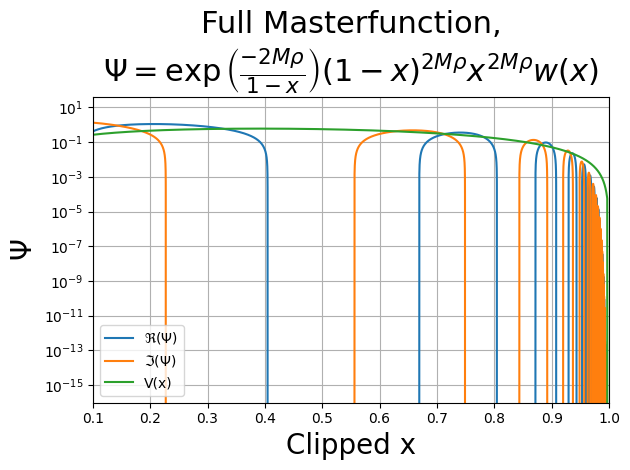

325.56408840978264


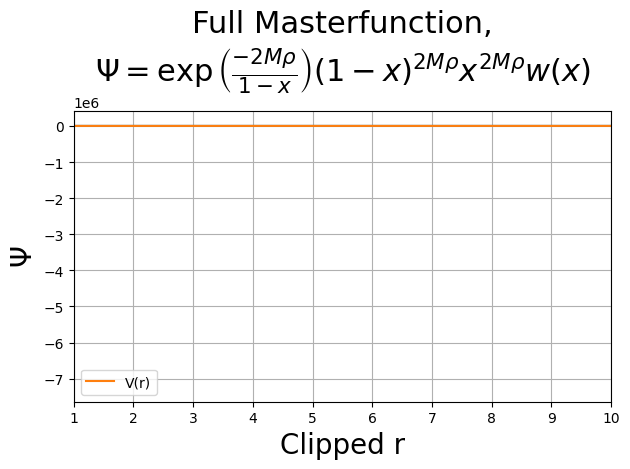

In [ ]:
cut = 1000
with t.no_grad():
    x_tensor = t.tensor(x_grid).to(DTYPE).view(-1, 1)
    w_out = model(x_tensor).numpy()
    plt.figure()
    plt.plot(x_grid, w_out[:, 0], label = r'$\Re(w(x))$')
    plt.plot(x_grid, w_out[:, 1], label = r'$\Im(w(x))$')
    plt.plot(x_grid, V_PINN, color = 'green', label = 'V(x)')
    plt.xlabel('x', fontsize = 20)
    plt.ylabel('w(x) & V(x)', fontsize = 20)
    plt.title('PINN Eigenfunction solution, w(x)', fontsize = 22)
    plt.tight_layout()
    plt.grid()
    plt.legend()
    plt.show()

    rho = complex(model.rho_re.item(), model.rho_im.item())
    omega = complex(0, 1)*rho
    Psi = np.exp(-x_grid*rho/(x_grid - 1))*(1 - x_grid)**(-2*rho)*(x_grid/(1 - x_grid))**(rho)*(w_out[:, 0] + complex(0,1)*w_out[:, 1])
    

    plt.figure()
    plt.plot(x_grid[:len(x_grid) - cut], Psi.real[:len(x_grid) - cut], label = r'$\Re(\Psi)$')
    plt.plot(x_grid[:len(x_grid) - cut], Psi.imag[:len(x_grid) - cut], label = r'$\Im(\Psi)$')
    plt.plot(x_grid, V_PINN, label = 'V(x)')
    plt.yscale('log')
    plt.xlabel('Clipped x', fontsize = 20)
    plt.xlim(0.1, 1)
    plt.ylabel(r'$\Psi$', fontsize = 20)
    plt.title('Full Masterfunction,'
        '\n'
        r'$\Psi = \exp{\left(\frac{-2M \rho}{1 - x}\right)} (1 - x)^{2M \rho} x^{2M \rho} w(x)$', fontsize = 22)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    r_grid = x_to_r(x_grid, mass)
    h1 = r_grid*Psi/(1-1/r_grid)
    
    print(x_to_r(x_grid[-2], mass))
    plt.figure()
    # plt.plot(r_grid[:len(r_grid) - cut], Psi.real[:len(x_grid) - cut], label = r'$\Re(\Psi)$')
    # plt.plot(r_grid[:len(r_grid) - cut], Psi.imag[:len(x_grid) - cut], label = r'$\Im(\Psi)$')
    # plt.plot(r_grid, np.abs(Psi.real), label = r'$\Re(\Psi)$')
    # plt.plot(r_grid, np.abs(Psi.imag), label = r'$\Im(\Psi)$')
    # plt.plot(r_grid, np.abs(Psi))
    # plt.plot(r_grid, (Psi.real), label = r'$\Re(\Psi)$')
    plt.plot(r_grid, h1.real)
    plt.plot(r_grid, V_PINN, label = 'V(r)')
    plt.xlim(1, 10)
    # plt.yscale('log')
    # plt.xscale('log')
    plt.xlabel('Clipped r', fontsize = 20)
    plt.ylabel(r'$\Psi$', fontsize = 20)
    plt.title('Full Masterfunction,'
        '\n'
        r'$\Psi = \exp{\left(\frac{-2M \rho}{1 - x}\right)} (1 - x)^{2M \rho} x^{2M \rho} w(x)$', fontsize = 22)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

[-7.27247789e+06 -7.27247775e+06 -7.27247789e+06 ...  1.51879327e-24
  1.65721492e-24  0.00000000e+00]


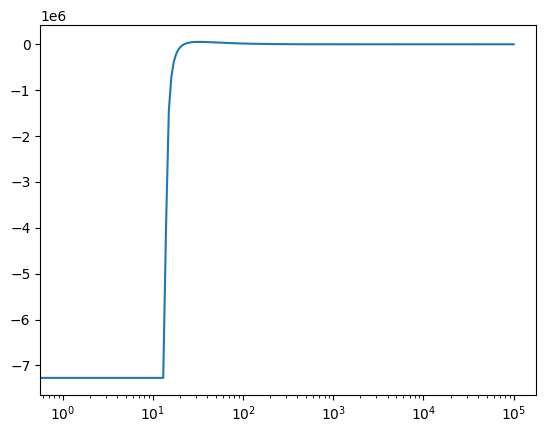

In [34]:
print(h1.real)
plt.plot(h1.real)
plt.xscale('log')
plt.show()

In [ ]:
def Psi(r, M):
    x = r_to_x(r, M)
    A = np.exp(-2*M*rho/(1-x))
    B = x**(2*M*rho)
    C = (1 - x)**(2*M*rho)
    return A*B*C*(complex(*model(t.tensor([x]))))

print(Psi(200, mass))

(4941522044.871071-31861675457.80518j)
